Uses envelope data to predict number of terms needed in each region.

In [1]:
import sys
from pathlib import Path
HERE = Path.cwd().resolve()
up1_path = str((HERE / ".." ).resolve())
up2_path = str((HERE / ".." / ".." ).resolve())
data1_prefix = str((HERE / ".." / "i-region-convergence").resolve())
data2_prefix = str((HERE / ".." / "e-region-convergence").resolve())
data3_prefix = str((HERE / "data" ).resolve())
for pathstr in [up1_path, up2_path]:
  if pathstr not in sys.path:
      sys.path.insert(0, pathstr)

from helpers import *
import numpy as np
from prediction_evaluators import *
import copy

In [2]:
def unshielded(cf):
  if len(cf["d"]) < 3: return True
  for i in range(2, len(cf["d"])):
    if (cf["h"] - cf["d"][i]) < (cf["h"] - cf["d"][1]): return False
  return True

def filter_unshielded(cfs):
  return [cf for cf in cfs if unshielded(cf)]


In [3]:
random_data_1 = open_pkl_file(data3_prefix + "/random-three-body-regions.pkl")
random_data_2 = open_pkl_file(data3_prefix + "/random-four-body-regions.pkl")

def convert_to_typical(random_data, heave, region):
  def new_cf(cf):
    m0 = cf["m0s"][0]
    return {"h" : cf["h"],
            "d" : cf["d"],
            "a" : cf["a"],
            "m0s" : cf["m0s"],
            m0 : {"am" : cf[m0][heave]["am"],
                  "dp" : cf[m0][heave]["dp"],
                  "ams" : cf[m0][heave][region]["ams"],
                  "dps" : cf[m0][heave][region]["dps"]}}
  return [new_cf(cf) for cf in random_data]

test_set_00 = (filter_unshielded(convert_to_typical(random_data_1, 0, 0) + convert_to_typical(random_data_2, 0, 0)))
test_set_11 = (convert_to_typical(random_data_1, 1, 1))# + convert_to_typical(random_data_2, 1, 1) + convert_to_typical(random_data_2, 2, 2))
test_set_22 = (convert_to_typical(random_data_1, 2, 2))# + convert_to_typical(random_data_2, 3, 3))
test_set_ext = (convert_to_typical(random_data_1, 2, 3))# + convert_to_typical(random_data_2, 3, 4))

for test_set in [test_set_00, test_set_11, test_set_22, test_set_ext]:
  generate_convergence_data(test_set, [0.01])
  _ = generate_log_data(test_set)

test_set_00 = filter_converged(test_set_00)
test_set_11 = filter_converged(test_set_11)
test_set_22 = filter_converged(test_set_22)
    

In [4]:
def sigmoid(a, b, c, x):
  return (b/(1 + np.exp(-a*(x-1)))) + c

def tanh_like(a, b, c, x): # Same as sigmoid with these fit parameter options
  return (b * (1 + np.tanh(a*(x-1)))) + c

def square_root(a, b, c, x):
  return a * np.sqrt(x+c) + b

def log_like(a, b, c, x):
  return a * np.log(x+c) + b

def linear(a, b, x):
  return a * x + b

def lennard_jones(a1, a2, b1, b2, c1, c2, x):
  return a1/(np.power((x-c1), b1)) - a2/(np.power((x-c1), b2)) + c2

def buckingham(a1, a2, b1, b2, c1, c2, x):
  return a1*np.exp(- b1 * (x-c1)) - a2/(np.power((x-c1), b2)) + c2

def unshifted_power_law(a, b, x):
  return a * np.power(x, b)

def identify_sigmoid_tanh(curve):
  if curve == "sigmoid": return sigmoid
  elif curve == "tanh": return tanh_like
  else:
    print("Unrecognized curve type, defaulting to sigmoid.")
    return sigmoid

def identify_sqrt_log(alpha_str):
  if alpha_str == "sqrt": return square_root
  elif alpha_str == "log": return log_like
  else:
    print("Unrecognized alpha function type, defaulting to log.")
    return log_like

def identify_lj_buck(name_str):
  if name_str == "lennard-jones": return lennard_jones
  elif name_str == "buckingham": return buckingham
  elif name_str == "constant": return lambda c : c
  else:
    print("Unrecognized function type, defaulting to constant.")
    return lambda c : c

def inner_model_curve_low(curve, alpha_str):
  curve_fcn = identify_sigmoid_tanh(curve)
  alpha_fcn = identify_sqrt_log(alpha_str)
  def model_vars(vars, a1, a2, b1, b2, c1, c2, a51, a52, a53, a6):
    hmdr, right_ratio = vars
    alpha = alpha_fcn(a1, b1, c1, hmdr) * (right_ratio < 1) + alpha_fcn(a2, b2, c2, hmdr) * (right_ratio >= 1)
    beta = (curve_fcn(a51, a52, a53, right_ratio) * hmdr) * (right_ratio < 1) + (a6 * hmdr) * (right_ratio >= 1)
    return alpha, beta
  
  variables_used = ["(h-d)/radwidth", "(h-d_out)/(h-d)"]
  guess = (1.44, 1.44, 0.03, 0.03, 1, 1, 0.2, 0.2, 0.2, 0.03)
  return model_vars, variables_used, guess

def inner_model_curve_low_combined(curve, alpha_str):
  curve_fcn = identify_sigmoid_tanh(curve)
  alpha_fcn = identify_sqrt_log(alpha_str)
  def model_vars(vars, a1, a2, b1, c1, c2, a51, a52, a53, a6):
    hmdr, right_ratio = vars
    alpha = alpha_fcn(a1, b1, c1, hmdr) * (right_ratio < 1) + alpha_fcn(a2, b1, c2, hmdr) * (right_ratio >= 1)
    beta = (curve_fcn(a51, a52, a53, right_ratio) * hmdr) * (right_ratio < 1) + (a6 * hmdr) * (right_ratio >= 1)
    return alpha, beta
  
  variables_used = ["(h-d)/radwidth", "(h-d_out)/(h-d)"]
  guess = (1.44, 1.44, 0.03, 1, 1, 0.2, 0.2, 0.2, 0.03)
  return model_vars, variables_used, guess

def inner_model_1_cutoff(cutoff):
  def model_vars(vars, a1, a2, a3, a4, a5, a6):
    hmdr, right_ratio = vars
    alpha = (a1 + a2 * hmdr) * (right_ratio < cutoff) + (a3 + a4 * hmdr) * (right_ratio >= cutoff)
    beta = (a5 * hmdr) * (right_ratio < cutoff) + (a6 * hmdr) * (right_ratio >= cutoff)
    return alpha, beta
  
  variables_used = ["(h-d)/radwidth", "(h-d_out)/(h-d)"]
  guess = (1.44, 0.03, 1.44, 0.03, 0.2, 0.03)
  return model_vars, variables_used, guess

In [5]:
def color_diff_plot(data, nmk_from_err_model, err, *params):
  sorted_data = sorted(sorted(data, key = lambda cf:(cf["h"]-cf["d"][0])/(cf["a"][0])), key=lambda cf:(cf["h"]-cf["d"][1])/(cf["h"]-cf["d"][0]))
  data = [{"am nmk actual" : convergence_point(cf[cf["m0s"][0]], "am", err),
           "am nmk predicted" : np.ceil(nmk_from_err_model(err, cf, cf["m0s"][0], *params))} for cf in sorted_data]
  right_ratios = [(cf["h"]-cf["d"][1])/(cf["h"]-cf["d"][0]) for cf in sorted_data]
  hmdrs = [(cf["h"]-cf["d"][0])/(cf["a"][0]) for cf in sorted_data]
  true_nmks = [cf["am nmk actual"] for cf in data]
  predicted_nmks = [cf["am nmk predicted"] for cf in data]
  v_min = min(min(true_nmks), min(predicted_nmks))
  v_max = max(max(true_nmks), max(predicted_nmks))
  plt.scatter(hmdrs, right_ratios, label = "Actual 1% convergence nmk", s=130, marker="D", c=true_nmks, cmap="inferno", vmin = v_min, vmax = v_max)
  plt.scatter(hmdrs, right_ratios, label = "Predicted 1% convergence nmk", s=1, marker="o",c=predicted_nmks,cmap="inferno", vmin = v_min, vmax = v_max)
  plt.legend()
  plt.colorbar()
  plt.show()

def nmk_on_y_plot(data, vars_to_alpha_beta_model):
  sorted_data = sorted(data, key = lambda cf:(cf["h"]-cf["d"][0])/(cf["a"][0]))
  data = evaluate_many_precomputed_geoms(sorted_data, vars_to_alpha_beta_model, vars_to_alpha_beta_model, 0.01)
  right_ratios = [(cf["h"]-cf["d"][1])/(cf["h"]-cf["d"][0]) for cf in sorted_data]
  hmdrs = [(cf["h"]-cf["d"][0])/(cf["a"][0]) for cf in sorted_data]
  true_nmks = [cf["am nmk actual"] for cf in data]
  predicted_nmks = [cf["am nmk predicted"] for cf in data]
  xs = range(len(true_nmks))
  plt.scatter(xs, true_nmks, label = "Actual 1% convergence nmk", s=10, marker="D", c=right_ratios, cmap="inferno")
  plt.scatter(xs, predicted_nmks, label = "Predicted 1% convergence nmk", s=1, marker="o",c=right_ratios,cmap="inferno")
  plt.legend()
  plt.colorbar()
  plt.show()

def single_param_plot(ax, xs, ys1, ys2, param_name, var_name):
  ax.scatter(xs, ys1, c = "blue", label = "Initial")
  ax.plot(xs, ys2, c = "orange", label = "Fitted")
  ax.set_ylabel(param_name)
  ax.set_xlabel(var_name)

def param_predict_plots(cfs, cf_params_to_alpha_beta, params, hydro, var_func, var_name):
  pack = multi_fit_parameters(cfs, var_func, hydro, print_params = False, plot_multi_log_comparison = False, plot_multi_params = False, nmk_max = 150)
  xs, init_alphas, init_betas = pack[0], pack[1], pack[2]
  pred_alphas, pred_betas = [], []
  for cf in cfs:
    for m0 in cf["m0s"]:
      alpha, beta = cf_params_to_alpha_beta(cf, m0, *params)
      pred_alphas.append(alpha)
      pred_betas.append(beta)
  fig, axs = plt.subplots(1, 2, figsize = (8, 4))
  single_param_plot(axs[0], xs, init_alphas, pred_alphas, "alpha", var_name)
  single_param_plot(axs[1], xs, init_betas, pred_betas, "beta", var_name)
  axs[1].legend()
  fig.show()


In [6]:
file4 = data1_prefix + "/innermost-region/data/predetermined-2.pkl"
f4_data = open_pkl_file(file4)
generate_convergence_data(f4_data, [0.01])
generate_log_data(f4_data)
f4_data = filter_converged(f4_data)

low_rr = lambda cf, lim: (cf["h"]-cf["d"][1])/(cf["h"]-cf["d"][0]) <= lim
high_rr = lambda cf, lim : (cf["h"]-cf["d"][1])/(cf["h"]-cf["d"][0]) > lim

f4_data_high_cutoff = [cf if (low_rr(cf, 1) and high_rr(cf, 0.8)) else filter_one_convergence_plus(copy.deepcopy(cf), 20) for cf in f4_data]

f4_data_low = [cf for cf in f4_data if low_rr(cf, 0.9)]
f4_data_mid = [cf for cf in f4_data if not(low_rr(cf, 0.9) or high_rr(cf, 1))]
f4_data_high = [cf for cf in f4_data if high_rr(cf, 1)]
f4_data_substep = f4_data_low + f4_data_high

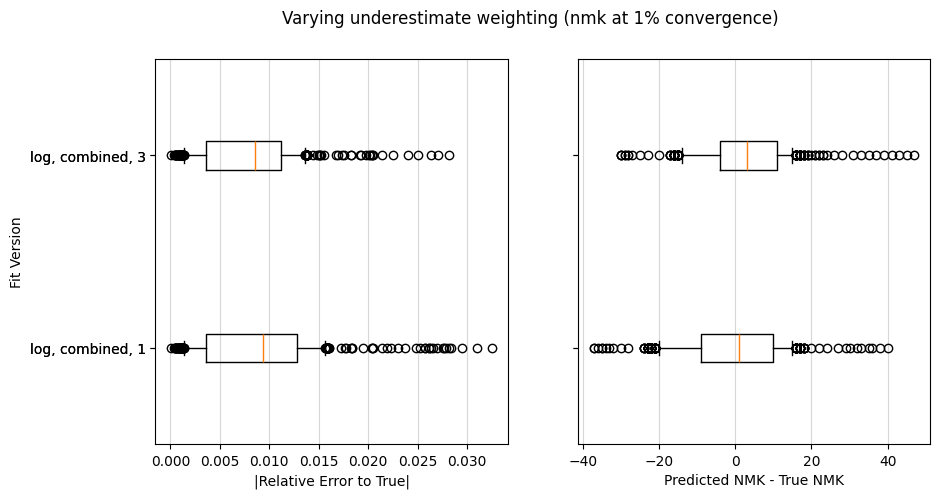

Sample size: 1420
Average Errors: 0.00883,0.00785
STDEV Errors: 0.00524,0.00434
Average NMK off: -0.169,2.55
STDEV NMK off: 11.7,9.99


In [7]:
# pack1 = variables_guess_variants(inner_model_curve_low, "innermost", "sigmoid", "sqrt")
# pack2 = variables_guess_variants(inner_model_curve_low, "innermost", "sigmoid", "log")
pack3 = variables_guess_variants(inner_model_curve_low_combined, "innermost", "sigmoid", "log")
packs = [pack3]
fcn_names = ["log, combined,"] # ["sqrt", "log", "log, combined,"]

cfs, hydro = f4_data, "am"
params_dict= {}
underweight_lst = [1, 3]
for i in range(1):
  pack, fcn_name = packs[i], fcn_names[i]
  variables_used, guess, fit_model, cf_params_to_alpha_beta, err_from_nmk_model, nmk_from_err_model = pack
  for underweight in underweight_lst:
    params, res = fit_inner_model_weighted(cfs, hydro, fit_model, guess, variables_used, underweight = underweight)
    key = fcn_name + " " + str(underweight)
    params_dict[key] = (twenty_minimum(nmk_from_err_model), params)
statpacks = compare_abs_nmk_rel_err(f4_data, hydro, params_dict, 0.01, nmk_big = 200, title = "Varying underestimate weighting (nmk at 1% convergence)")
print_err_nmk_abs_from_statpacks(statpacks)

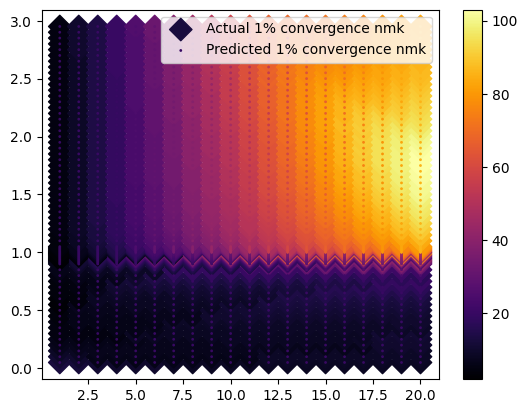

In [8]:
color_diff_plot(f4_data, params_dict["log, combined, 3"][0], 0.01, *params_dict["log, combined, 3"][1])

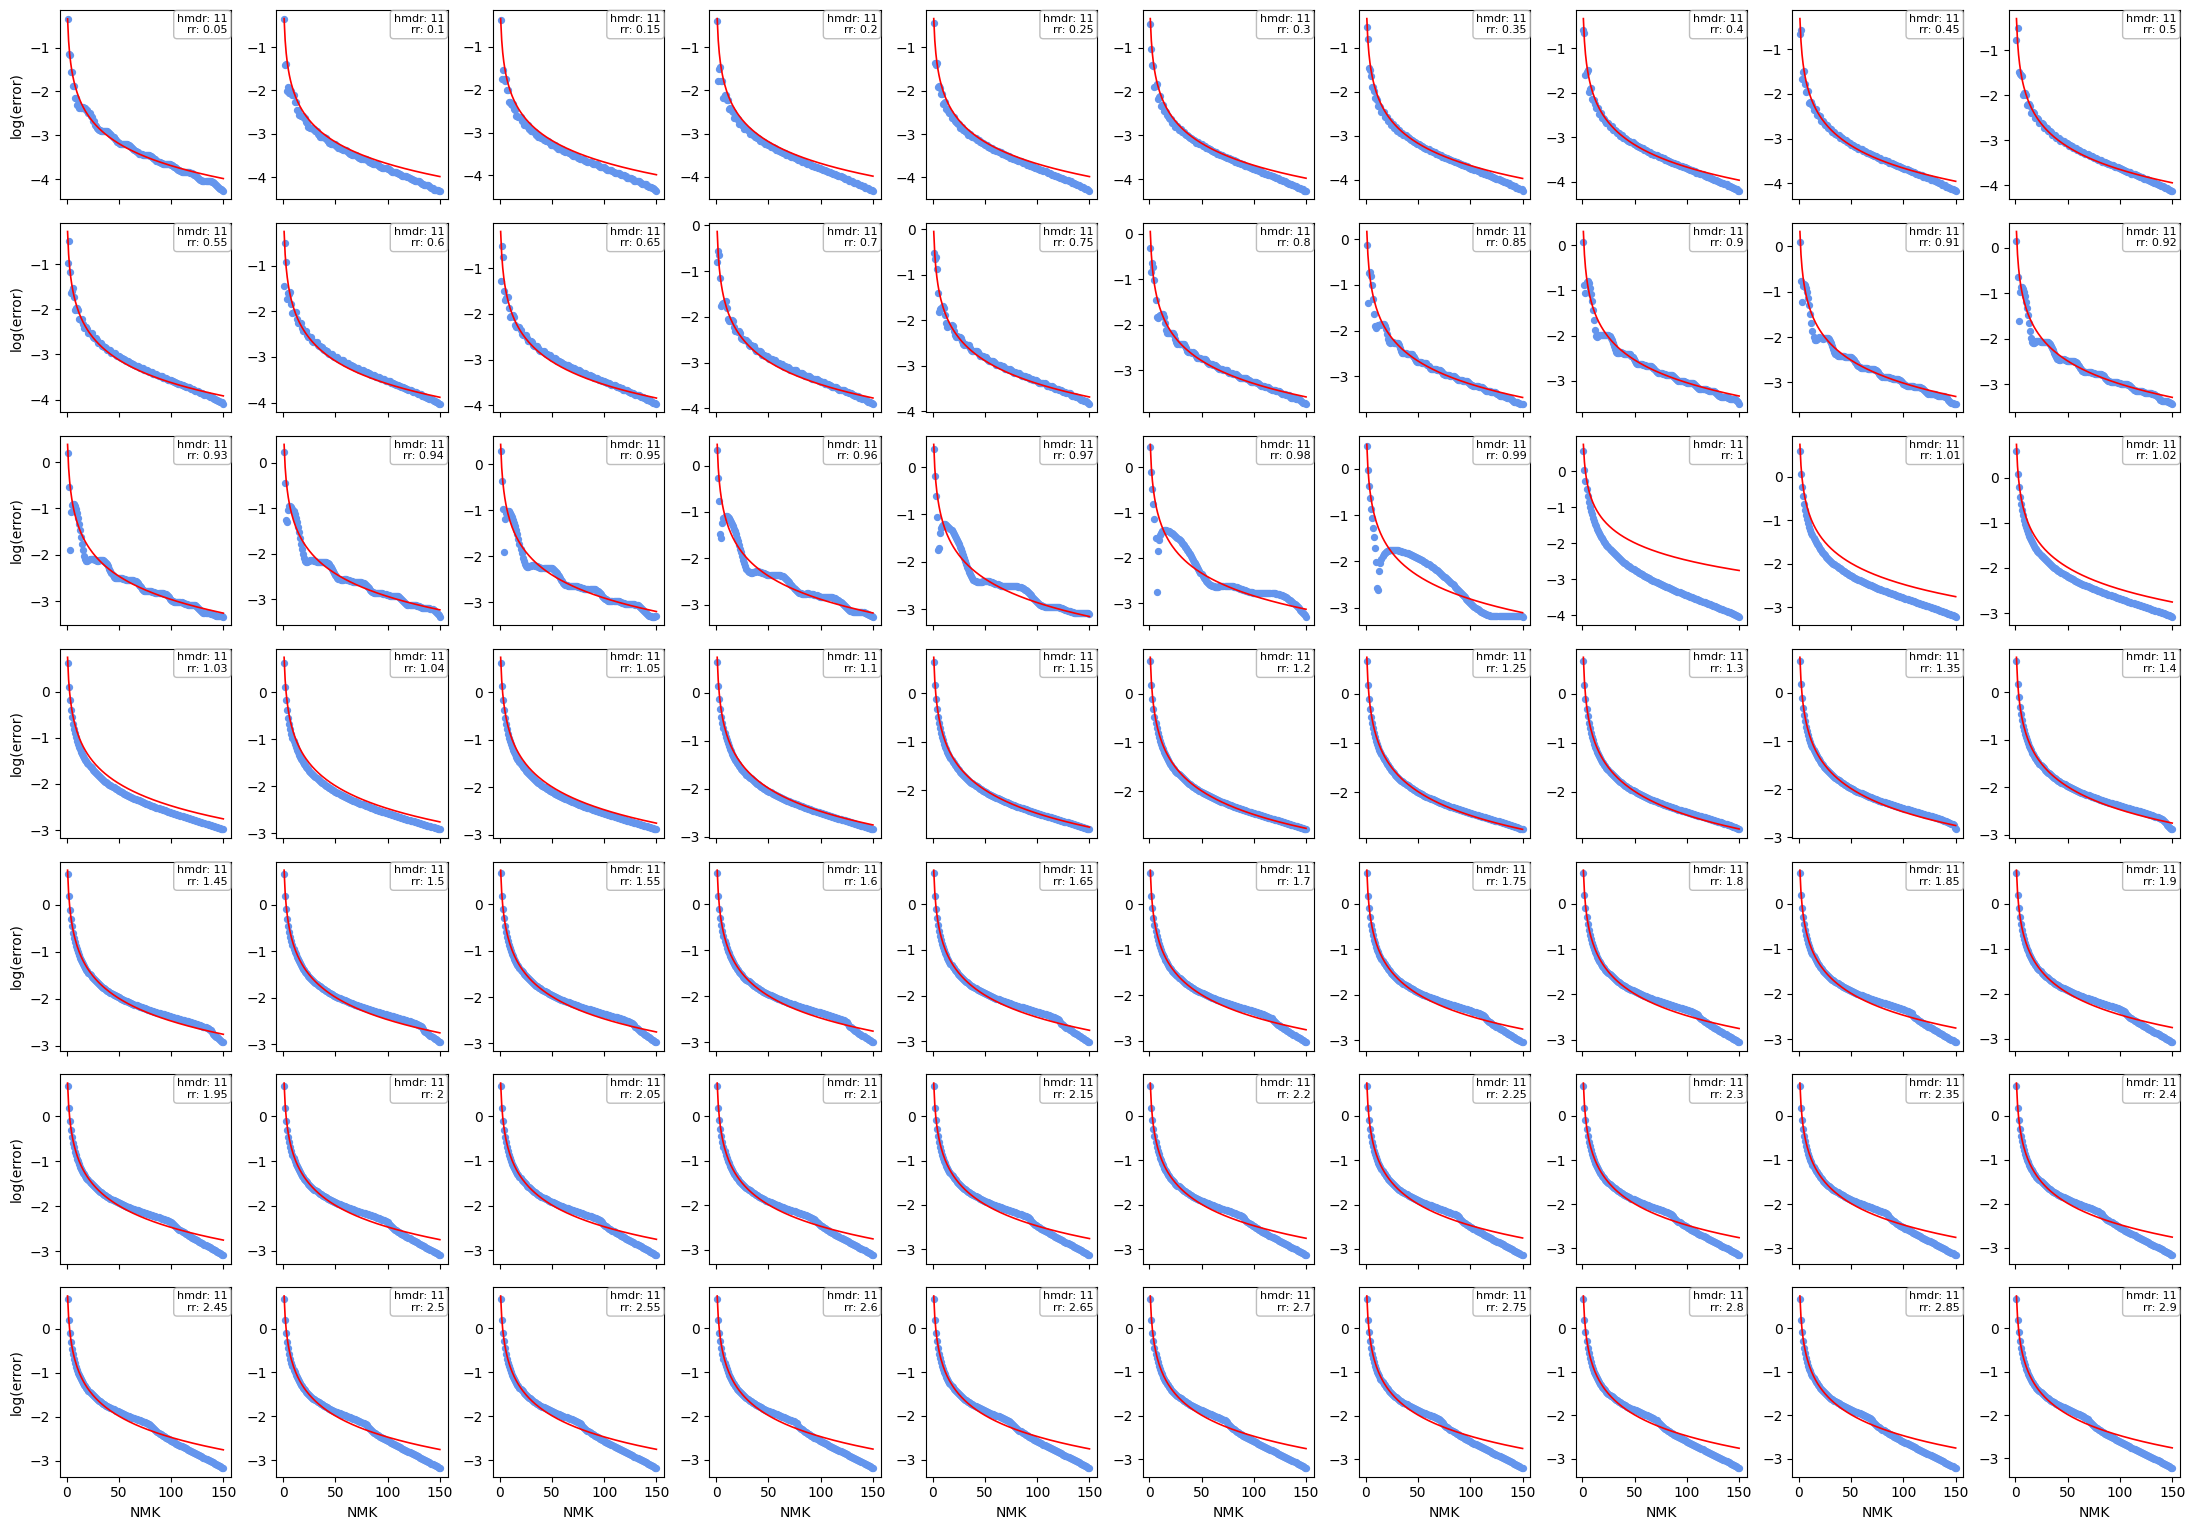

In [11]:
summary_fs = {"hmdr" : lambda cf : (cf["h"]-cf["d"][0])/cf["a"][0],
              "rr" : lambda cf : (cf["h"]-cf["d"][1])/(cf["h"]-cf["d"][0])}

err_from_nmk_full = lambda nmk : np.log10(err_from_nmk_model(nmk, params_dict["5"][1]))

sub_data = [f4_data[i] for i in range(10, 1400, 20)]
compare_model_curves(sub_data, extractf_am, model_wrapper(lambda cf, m0 : cf_params_to_alpha_beta(cf, m0, *params_dict["log, combined, 3"][1])), summary_fs)

In [13]:
file1 = data1_prefix + "/innermost-region/data/predetermined-8.pkl"
file5 = data1_prefix + "/innermost-region/data/predetermined-5.pkl"
file6 = data1_prefix + "/innermost-region/data/predetermined-6.pkl"
file7 = data1_prefix + "/innermost-region/data/random-innermost.pkl"
f1_data = open_pkl_file(file1)
f5_data = [filter_unshielded(cfs) for cfs in open_pkl_file(file5)]
f6_data = [filter_unshielded(cfs) for cfs in open_pkl_file(file6)]
for pset in f1_data:
  generate_convergence_data(pset, [0.01])
  generate_log_data(pset)
for pset in f5_data:
  generate_convergence_data(pset, [0.01])
  generate_log_data(pset)
for pset in f6_data:
  generate_convergence_data(pset, [0.01])
  generate_log_data(pset)
all_f1_data = [cf for pset in f1_data for cf in pset]
all_f5_data = [cf for pset in f5_data for cf in pset]
all_f6_data = [cf for pset in f6_data for cf in pset]

f7_data = open_pkl_file(file7)
generate_convergence_data(f7_data, [0.01])
f7_data = filter_unshielded(filter_converged(f7_data))
_ = generate_log_data(f7_data)

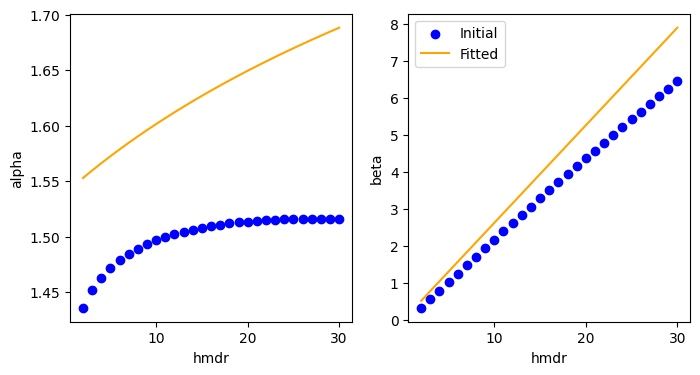

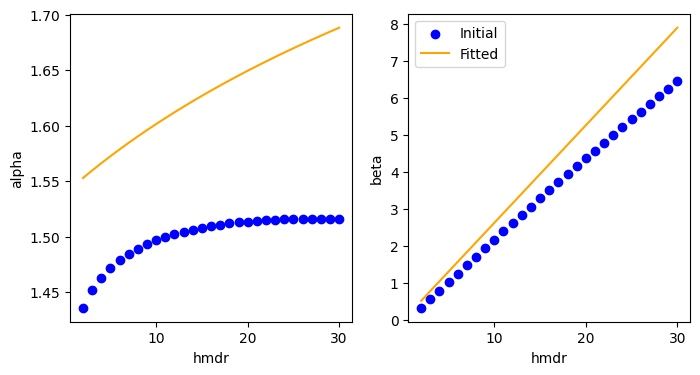

In [42]:
# triples = [(f4_data[100:121], lambda cf, m0 : (cf["h"]-cf["d"][0])/(cf["a"][0]), "hmdr"),
#             (f4_data[1000:1021], lambda cf, m0 : (cf["h"]-cf["d"][0])/(cf["a"][0]), "hmdr"),
#             ([f4_data[i] for i in range(19, 1400, 20)], lambda cf, m0 : (cf["h"]-cf["d"][1])/(cf["h"]-cf["d"][0]), "right ratio"),
#             ([f4_data[i] for i in range(9, 1400, 20)], lambda cf, m0 : (cf["h"]-cf["d"][1])/(cf["h"]-cf["d"][0]), "right ratio")]

triples = [(f1_data[1], lambda cf, m0 : (cf["h"]-cf["d"][0])/(cf["a"][0]), "hmdr"),
           (f1_data[1], lambda cf, m0 : (cf["h"]-cf["d"][0])/(cf["a"][0]), "hmdr"),]

for triple in triples:
  # param_predict_plots(triple[0], cf_params_to_alpha_beta, params_dict["sqrt 1"][1], hydro, triple[1], triple[2])
  param_predict_plots(triple[0], cf_params_to_alpha_beta, params_dict["log, combined, 3"][1], hydro, triple[1], triple[2])

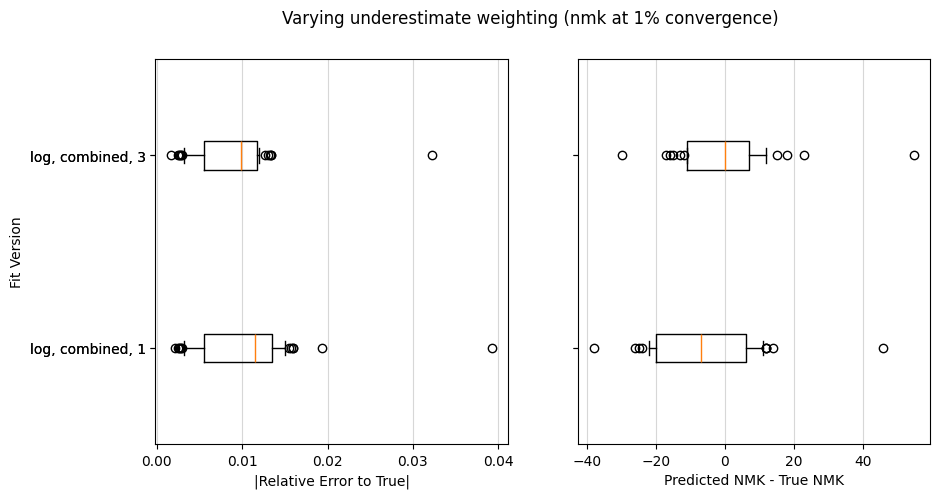

Sample size: 115
Average Errors: 0.0102,0.00891
STDEV Errors: 0.00497,0.00393
Average NMK off: -6.18,-0.757
STDEV NMK off: 13.5,10.7


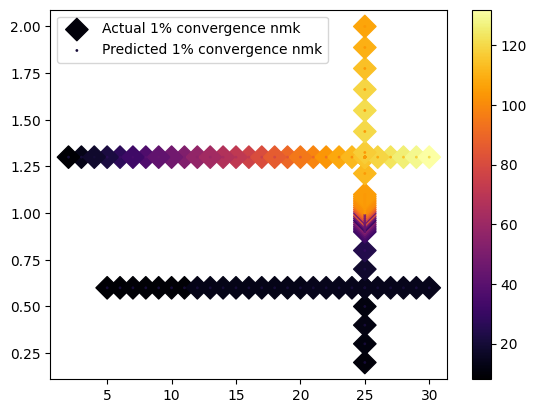

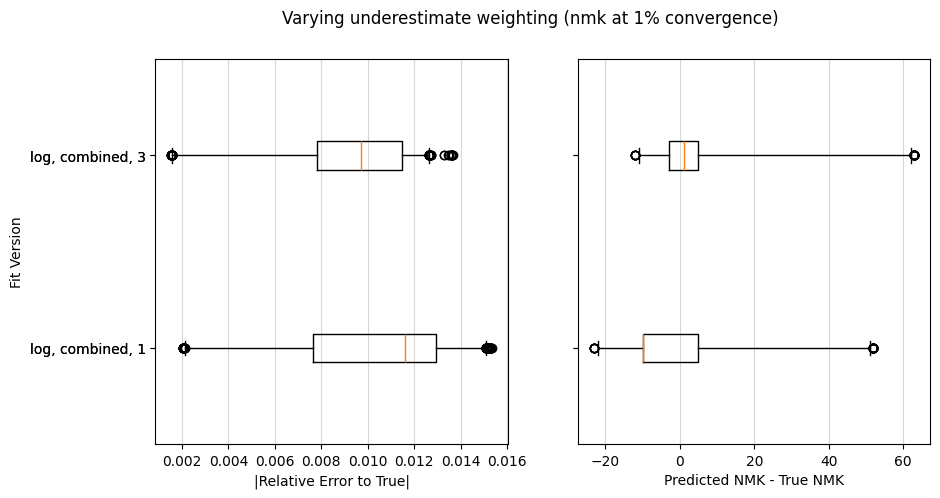

Sample size: 802
Average Errors: 0.0104,0.00908
STDEV Errors: 0.0038,0.00316
Average NMK off: -2.25,6.01
STDEV NMK off: 18.4,18.4


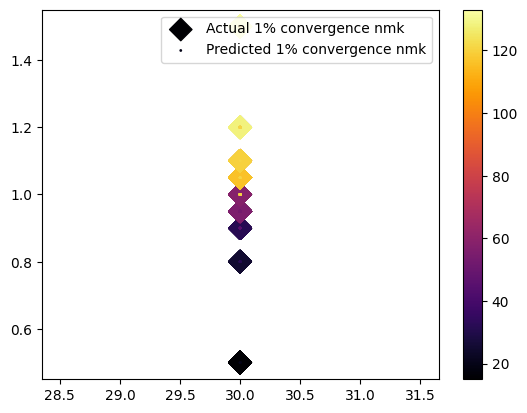

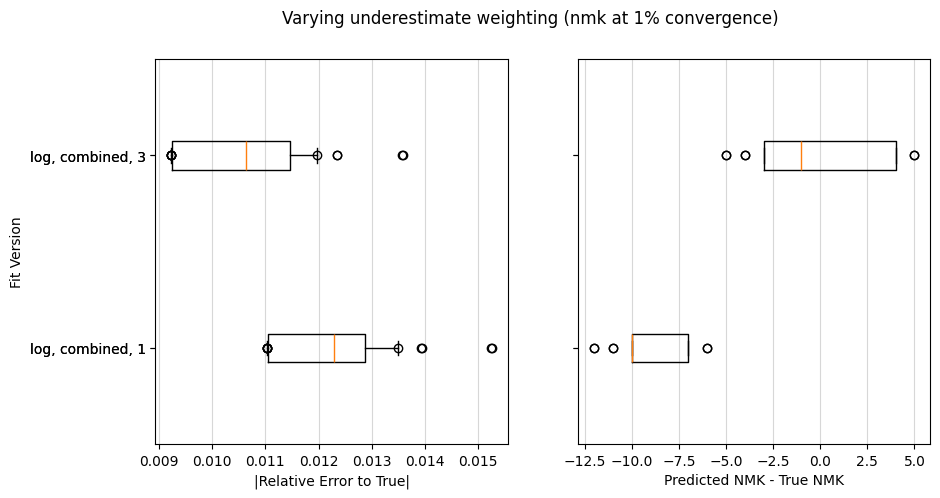

Sample size: 90
Average Errors: 0.0121,0.0105
STDEV Errors: 0.00104,0.0012
Average NMK off: -8.88,0.122
STDEV NMK off: 1.53,3.37


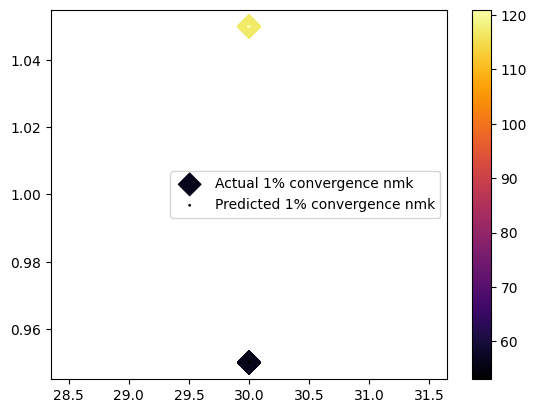

In [14]:
for dataset in [all_f1_data, all_f5_data, all_f6_data]:
  statpacks = compare_abs_nmk_rel_err(dataset, hydro, params_dict, 0.01, nmk_big = 200, title = "Varying underestimate weighting (nmk at 1% convergence)")
  print_err_nmk_abs_from_statpacks(statpacks)
  color_diff_plot(dataset, params_dict["log, combined, 3"][0], 0.01, *params_dict["log, combined, 3"][1])

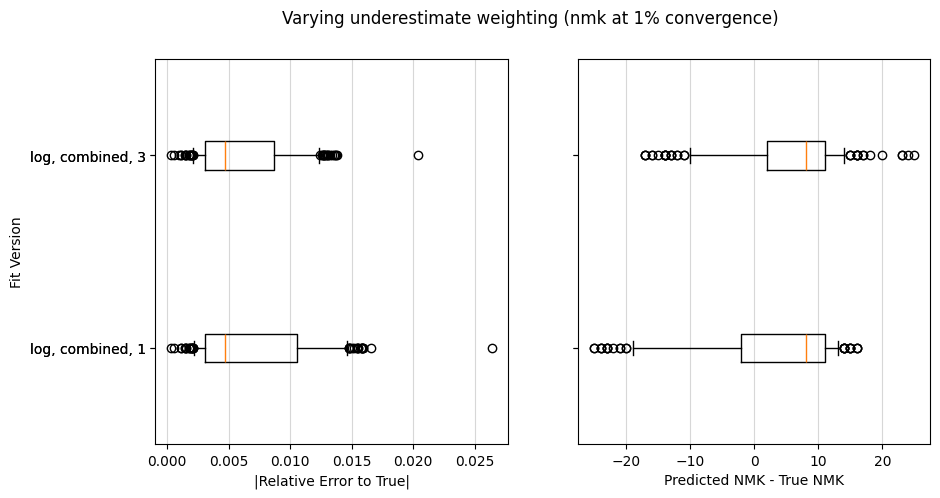

Sample size: 349
Average Errors: 0.00666,0.00594
STDEV Errors: 0.00439,0.00352
Average NMK off: 3.72,5.93
STDEV NMK off: 9.84,7.74


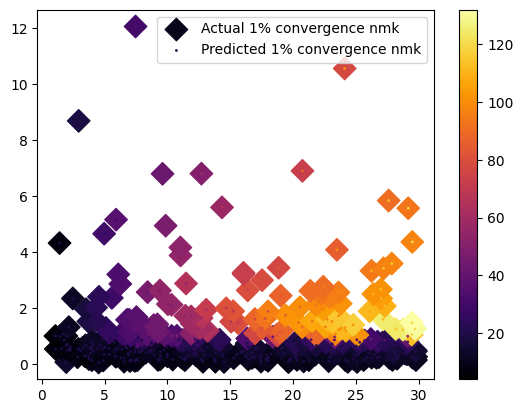

In [16]:
statpacks = compare_abs_nmk_rel_err(test_set_00, "am", params_dict, 0.01, nmk_big = 200, title = "Varying underestimate weighting (nmk at 1% convergence)")
print_err_nmk_abs_from_statpacks(statpacks)
color_diff_plot(test_set_00, params_dict["log, combined, 3"][0], 0.01, *params_dict["log, combined, 3"][1])

In [17]:
# Moving onto middle region
file2 = data1_prefix + "/middle-region/data/predetermined-4.pkl"
f2_data = open_pkl_file(file2)
all_f2_data = [cf for pset in f2_data for cf in pset]
generate_convergence_data(all_f2_data, [0.01])
_ = generate_log_data(all_f2_data)

file8 = data1_prefix + "/middle-region/data/predetermined-1.pkl"
file9 = data1_prefix + "/middle-region/data/predetermined-2.pkl"
file10 = data1_prefix + "/middle-region/data/predetermined-3.pkl"
data8 = open_pkl_file(file8)
data9_t = open_pkl_file(file9)
data9 = [cf for key in data9_t.keys() for cf in data9_t[key]]
data10 = [cf for pset in open_pkl_file(file10) for cf in pset]
other_middle_data = [data8] + [data9] + [data10]
for subset in other_middle_data:
  generate_convergence_data(subset, [0.01])
  _ = generate_log_data(subset)

In [36]:
def double_sided_model_curve_low(curve1, curve2, alpha_str):
  curve1_fcn = identify_sigmoid_tanh(curve1)
  # curve2_fcn = identify_sigmoid_tanh(curve2)
  alpha_fcn = identify_sqrt_log(alpha_str)
  def model_vars(vars, a1, a2, a3, a4, b1, c1, a51, a52, a53, a6, a7, a8):
    hmdr, left_ratio, right_ratio = vars
    a0 = ((a1 * (right_ratio < 1) + a2 * (right_ratio >= 1)) * (left_ratio < 1)
          + (a3 * (right_ratio < 1) + a4 * (right_ratio >= 1)) * (left_ratio >= 1))
    alpha = alpha_fcn(a0, b1, c1, hmdr)
    beta1 = (curve1_fcn(a51, a52, a53, right_ratio) * (right_ratio < 1) + a6 * (right_ratio >= 1))
    beta2 = a7 * (left_ratio < 1) + a8 * (left_ratio >= 1)
    # beta2 = (curve2_fcn(a71, a72, a73, left_ratio) * (left_ratio < 1) + a8 * (left_ratio >= 1))
    return alpha, beta1 * beta2 * hmdr

  variables_used = ["(h-d)/radwidth", "(h-d_in)/(h-d)", "(h-d_out)/(h-d)"]
  guess = (0.023, 0.023, 0.023, 0.023, 1.44, 1,
           0.2, 0.2, 0.2, 0.03, 0.2, 0.03)
  return model_vars, variables_used, guess

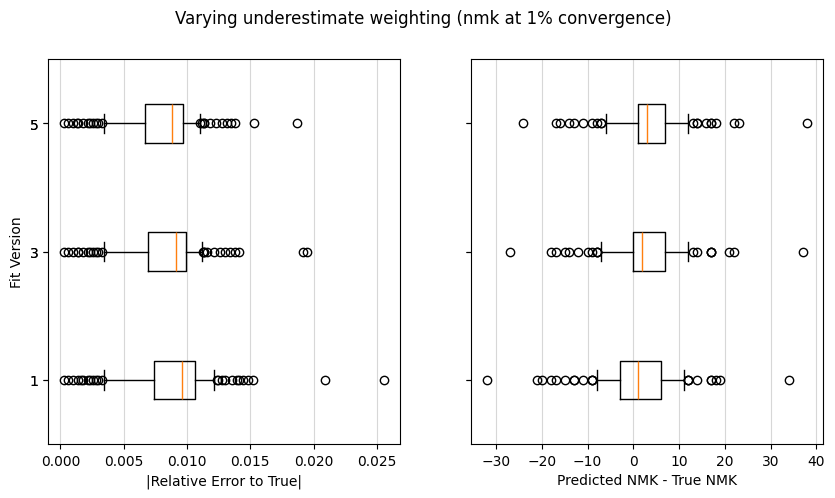

Sample size: 222
Average Errors: 0.0089,0.00838,0.00815
STDEV Errors: 0.00309,0.00273,0.0026
Average NMK off: 0.896,2.73,3.57
STDEV NMK off: 7.14,6.65,6.46


In [37]:
model_pack = variables_guess_variants(double_sided_model_curve_low, "middle", "sigmoid", "sigmoid", "log")
variables_used, guess, fit_model, cf_params_to_alpha_beta, err_from_nmk_model, nmk_from_err_model = model_pack
cfs, hydro = all_f2_data, "am"
params_dict= {}
underweight_lst = [1, 3, 5]
for underweight in underweight_lst:
  params, res = fit_middle_model_weighted(cfs, hydro, fit_model, guess, variables_used,  underweight = underweight)
  key = str(underweight)
  params_dict[key] = (twenty_minimum(nmk_from_err_model), params)
statpacks = compare_abs_nmk_rel_err(all_f2_data, hydro, params_dict, 0.01, nmk_big = 200, title = "Varying underestimate weighting (nmk at 1% convergence)")
print_err_nmk_abs_from_statpacks(statpacks)

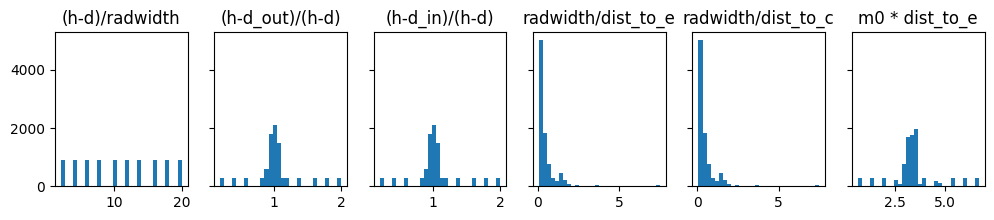

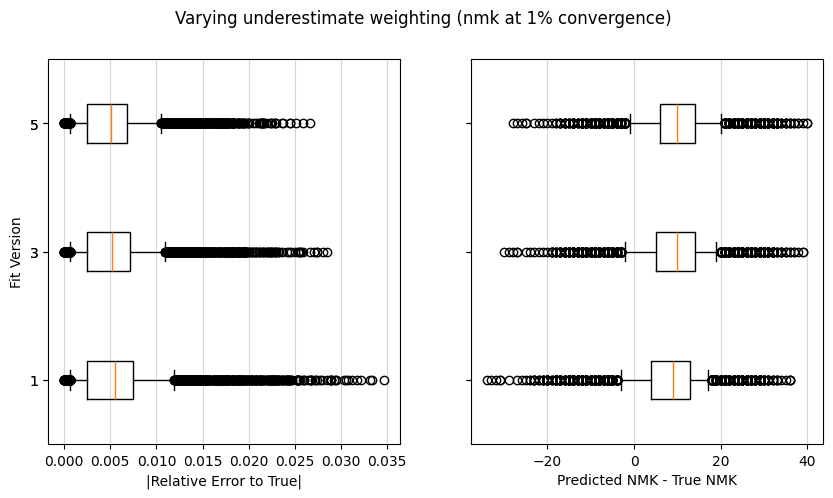

Sample size: 9000
Average Errors: 0.00565,0.00531,0.00512
STDEV Errors: 0.0041,0.00364,0.0034
Average NMK off: 8.14,9.12,9.72
STDEV NMK off: 7.11,6.95,6.87


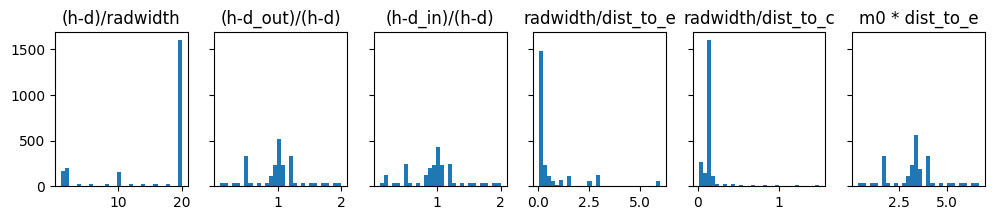

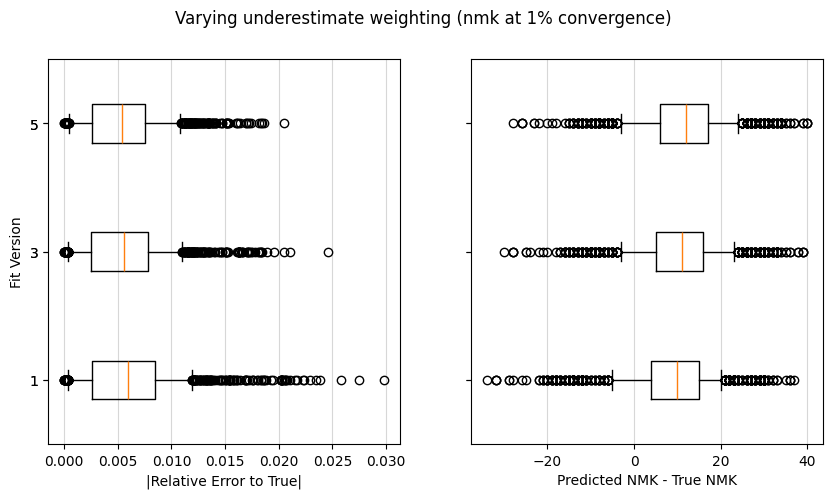

Sample size: 2317
Average Errors: 0.0059,0.00551,0.00533
STDEV Errors: 0.00406,0.0036,0.0034
Average NMK off: 9,10.4,11.2
STDEV NMK off: 9.03,8.67,8.49


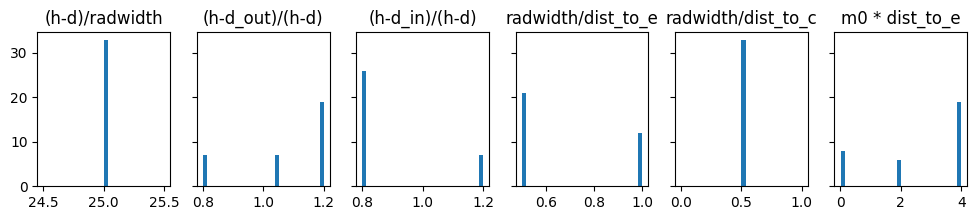

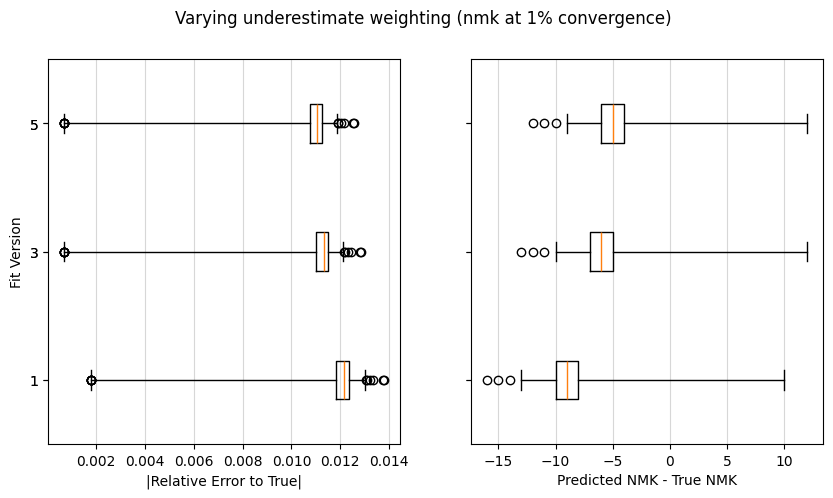

Sample size: 113
Average Errors: 0.0103,0.00945,0.00925
STDEV Errors: 0.00401,0.00411,0.00401
Average NMK off: -5.89,-3.07,-2.25
STDEV NMK off: 7.82,7.46,7.1


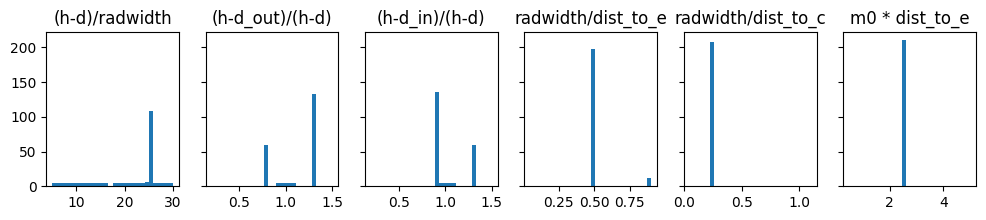

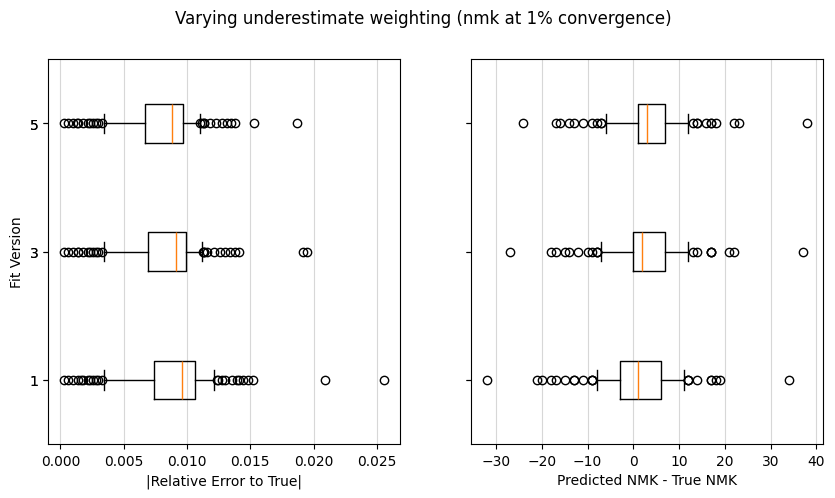

Sample size: 222
Average Errors: 0.0089,0.00838,0.00815
STDEV Errors: 0.00309,0.00273,0.0026
Average NMK off: 0.896,2.73,3.57
STDEV NMK off: 7.14,6.65,6.46


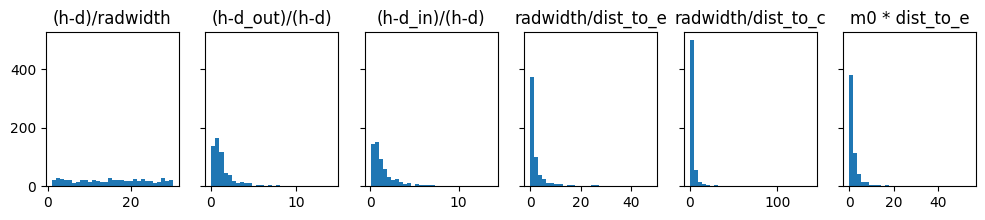

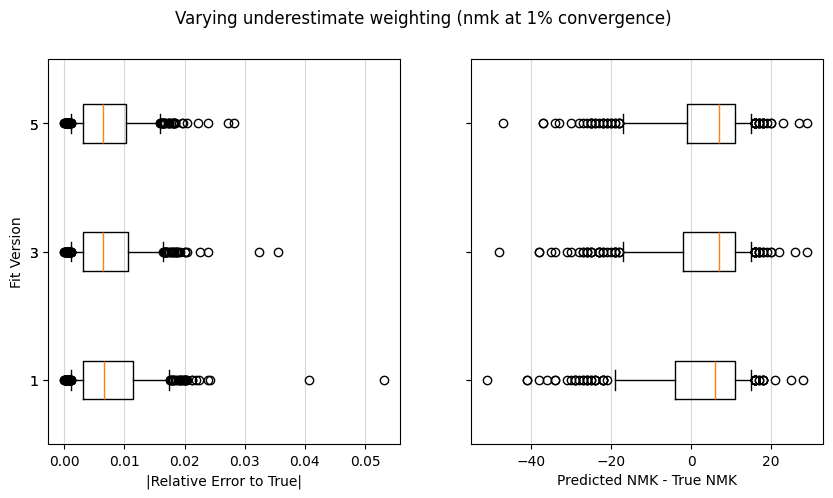

Sample size: 600
Average Errors: 0.00768,0.00731,0.00715
STDEV Errors: 0.00564,0.00502,0.00478
Average NMK off: 2.44,3.3,3.7
STDEV NMK off: 11.5,10.8,10.5


In [38]:
for dataset in other_middle_data + [all_f2_data] + [test_set_11]:
  ref = middle_vars(1,[1,2,3],[1,2,3],1, 1)
  middle_vars_collection = [middle_vars_cf(cf, cf["m0s"][0]) for cf in dataset]
  middle_vars_dict = {key : [cf[key] for cf in middle_vars_collection] for key in ref.keys()}
  fig, axs = plt.subplots(1, 6, figsize = (12, 2), sharey=True)
  count = 0
  for key in ref.keys():
    axs[count].hist(middle_vars_dict[key], bins = 30)
    axs[count].set_title(key)
    count+=1
  plt.show()
  statpacks = compare_abs_nmk_rel_err(dataset, hydro, params_dict, 0.01, nmk_big = 200, title = "Varying underestimate weighting (nmk at 1% convergence)")
  print_err_nmk_abs_from_statpacks(statpacks)

In [22]:
# Moving onto outermost region
file3 = data1_prefix + "/outermost-region/data/predetermined-2.pkl"
f3_data = open_pkl_file(file3)
# generate_convergence_data(f3_data[3], [0.01])
# f3_data[3] = [filter_one_convergence_plus(copy.deepcopy(cf), 10) for cf in f3_data[3]]
all_f3_data = [cf for pset in f3_data for cf in pset]

file11 = data1_prefix + "/outermost-region/data/predetermined-1.pkl"
all_f11_data = open_pkl_file(file11)
all_f11_data = [cf for key in all_f11_data.keys() for cf in all_f11_data[key]]

file12 = data1_prefix + "/outermost-region/data/histogram-1.pkl"
f12_data = open_pkl_file(file12)
all_f12_data = [cf for pset in f12_data for cf in pset]

file13 = data1_prefix + "/outermost-region/data/histogram-2.pkl"
f13_data = open_pkl_file(file13)
all_f13_data = [cf for pset in f13_data for cf in pset]

all_data = [all_f3_data, all_f11_data, all_f12_data, all_f13_data]
for i in range(len(all_data)):
  generate_convergence_data(all_data[i], [0.01])
  _ = generate_log_data(all_data[i])
  all_data[i] = filter_converged(all_data[i])
all_f3_data, all_f11_data, all_f12_data, all_f13_data = all_data

In [27]:
def outer_model_lj(m0_curve):
  m0_curve_fcn = identify_lj_buck(m0_curve)
  def model_vars(vars, a1, b1, a2, b2, b3,
                 a41, a42, a43, b4, a5, b5, a6, b6,
                 a71, a72, b71, b72, c71, c72): # 19 variables
    hmdr, left_ratio, right_ratio, rad_to_center, m0h = vars
    alpha1 = a1 * (left_ratio < 1) + b1 * (left_ratio >= 1)
    alpha2 = log_like(a2, b2, right_ratio)
    alpha = log_like(alpha1 * alpha2, b3, hmdr)
    beta1 = sigmoid(a41, a42, a43, left_ratio) * (left_ratio < 1) + b4 * (left_ratio >= 1)
    beta2 = log_like(a5, b5, right_ratio)
    beta3 = linear(a6, b6, rad_to_center)
    beta4 = m0_curve_fcn(a71, a72, b71, b72, c71, c72, m0h)
    beta = beta1 * beta2 * beta3 * beta4 * hmdr
    return alpha, beta
  
  variables_used = ["(h-d)/radwidth", "(h-d_in)/(h-d)", "h/(h-d)", "radwidth/dist_to_c", "m0h"]
  guess = [1.7, 1.1, 1.3, 1.2, 1.4,
           2, 0.2, 0.05, 0.2, 1.5, 1.4, 1.3, 1.2,
           4, 1, 1, 2, -1, 1]
  return model_vars, variables_used, guess

def outer_model_simplified():
  def model_vars(vars, a1, b1, a2, b2, c2, b3, c3,
                 a41, a42, a43, b4, a5, b5, c5, a6, b6): # 13 variables
    hmdr, left_ratio, right_ratio, rad_to_center = vars
    alpha1 = a1 * (left_ratio < 1) + b1 * (left_ratio >= 1)
    alpha2 = log_like(a2, b2, c2, right_ratio)
    alpha = log_like(alpha1 * alpha2, b3, c3, hmdr)
    beta1 = sigmoid(a41, a42, a43, left_ratio) * (left_ratio < 1) + b4 * (left_ratio >= 1)
    beta2 = log_like(a5, b5, c5, right_ratio)
    beta3 = linear(a6, b6, rad_to_center)
    beta = beta1 * beta2 * beta3 * hmdr
    return alpha, beta
  
  variables_used = ["(h-d)/radwidth", "(h-d_in)/(h-d)", "h/(h-d)", "radwidth/dist_to_c"]
  guess = [1.7, 1.1, 1.3, 1.2, 1, 1.4, 1,
           2, 0.2, 0.05, 0.2, 1.5, 1.4, 1, 1.3, 1.2]
  return model_vars, variables_used, guess

def outer_model_simplified_no_sigmoid():
  def model_vars(vars, a1, b1, a2, b2, c2, b3, c3,
                 a4, b4, a5, b5, c5, a6, b6): # 13 variables
    hmdr, left_ratio, right_ratio, rad_to_center = vars
    alpha1 = a1 * (left_ratio < 1) + b1 * (left_ratio >= 1)
    alpha2 = log_like(a2, b2, c2, right_ratio)
    alpha = log_like(alpha1 * alpha2, b3, c3, hmdr)
    beta1 = a4 * (left_ratio < 1) + b4 * (left_ratio >= 1)
    beta2 = log_like(a5, b5, c5, right_ratio)
    beta3 = linear(a6, b6, rad_to_center)
    beta = beta1 * beta2 * beta3 * hmdr
    return alpha, beta
  
  variables_used = ["(h-d)/radwidth", "(h-d_in)/(h-d)", "h/(h-d)", "radwidth/dist_to_c"]
  guess = [1.7, 1.1, 1.3, 1.2, 1, 1.4, 1,
           0.2, 0.2, 1.5, 1.4, 1, 1.3, 1.2]
  return model_vars, variables_used, guess

def outer_model_no_rad_ratio():
  def model_vars(vars, a1, b1, a2, b2, b3,
                 a41, a42, a43, b4, a5, b5): # 13 variables
    hmdr, left_ratio, right_ratio = vars
    alpha1 = a1 * (left_ratio < 1) + b1 * (left_ratio >= 1)
    alpha2 = log_like(a2, b2, right_ratio)
    alpha = log_like(alpha1 * alpha2, b3, hmdr)
    beta1 = sigmoid(a41, a42, a43, left_ratio) * (left_ratio < 1) + b4 * (left_ratio >= 1)
    beta2 = log_like(a5, b5, right_ratio)
    beta = beta1 * beta2 * hmdr
    return alpha, beta
  
  variables_used = ["(h-d)/radwidth", "(h-d_in)/(h-d)", "h/(h-d)"]
  guess = [1.7, 1.1, 1.3, 1.2, 1.4,
           2, 0.2, 0.05, 0.2, 1.5, 1.4]
  return model_vars, variables_used, guess

Finished a model.
Finished a model.


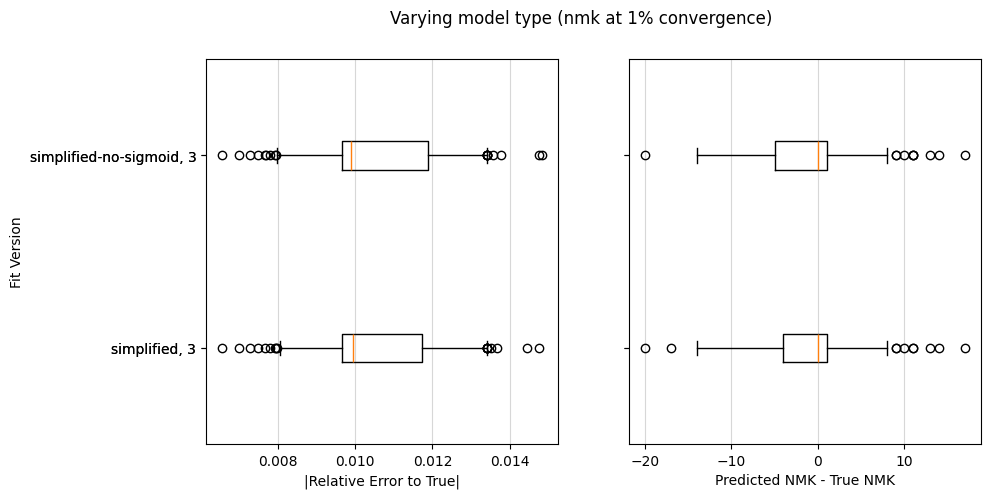

Sample size: 163
Average Errors: 0.0105,0.0105
STDEV Errors: 0.00164,0.00169
Average NMK off: -1.91,-1.96
STDEV NMK off: 6.13,6.22


In [28]:
cfs, hydro = all_f3_data, "am"
params_dict= {}
underweight_lst = [3]
# curve_names = ["lennard-jones", "buckingham", "simplified", "no rad ratio"]
# model_packs = [variables_guess_variants(outer_model_lj, "outermost", "lennard-jones"),
#                variables_guess_variants(outer_model_lj, "outermost", "buckingham"),
#                variables_guess_variants(outer_model_simplified, "outermost"),
#                variables_guess_variants(outer_model_no_rad_ratio, "outermost")]
curve_names = ["simplified", "simplified-no-sigmoid"]
model_packs = [variables_guess_variants(outer_model_simplified, "outermost"),
               variables_guess_variants(outer_model_simplified_no_sigmoid, "outermost"),]
for underweight in underweight_lst:
  for i in range(2):
    variables_used, guess, fit_model, cf_params_to_alpha_beta, err_from_nmk_model, nmk_from_err_model = model_packs[i]
    params, res = fit_outer_model_weighted(cfs, hydro, fit_model, guess, variables_used,  underweight = underweight)
    key = curve_names[i] + ", " + str(underweight)
    params_dict[key] = (twenty_minimum(nmk_from_err_model), params)
    print("Finished a model.")

statpacks = compare_abs_nmk_rel_err(all_f3_data, hydro, params_dict, 0.01, nmk_big = 200, title = "Varying model type (nmk at 1% convergence)")
print_err_nmk_abs_from_statpacks(statpacks)

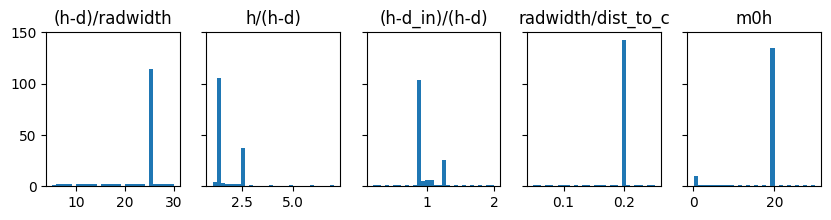

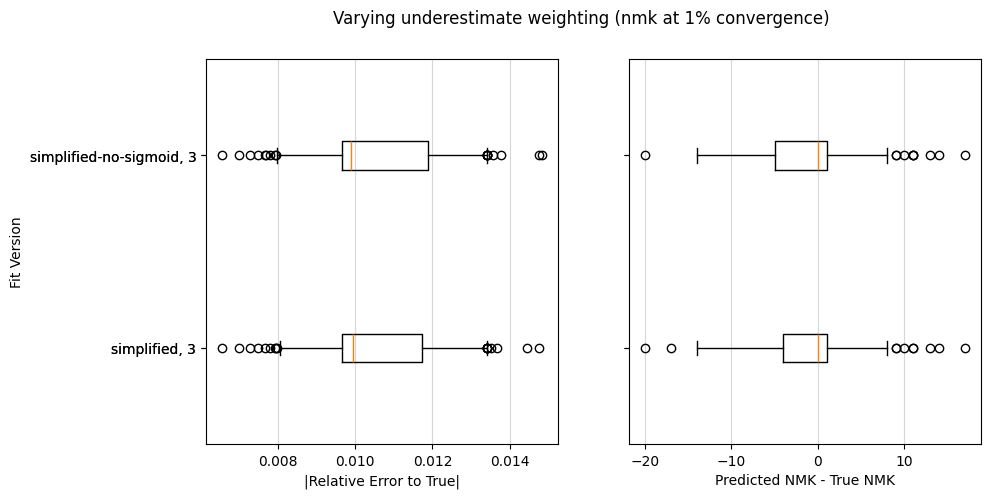

Sample size: 163
Average Errors: 0.0105,0.0105
STDEV Errors: 0.00164,0.00169
Average NMK off: -1.91,-1.96
STDEV NMK off: 6.13,6.22


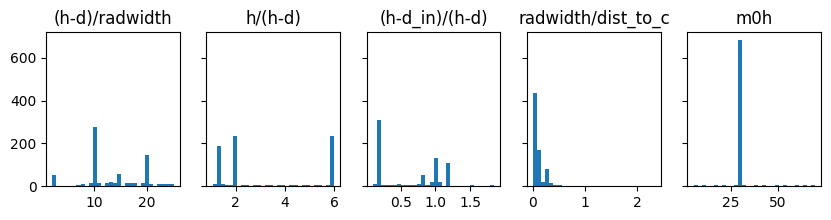

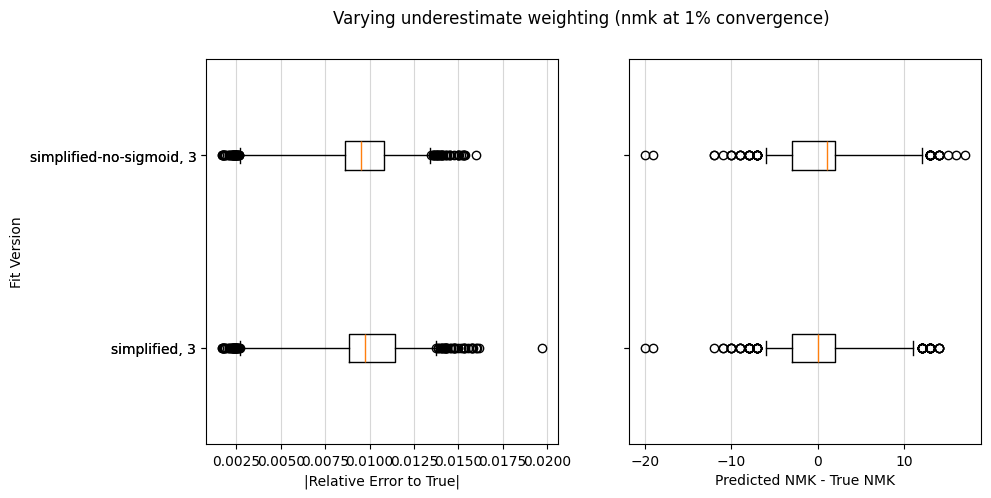

Sample size: 751
Average Errors: 0.00965,0.00915
STDEV Errors: 0.00286,0.0029
Average NMK off: 0.138,0.905
STDEV NMK off: 4.92,5.16


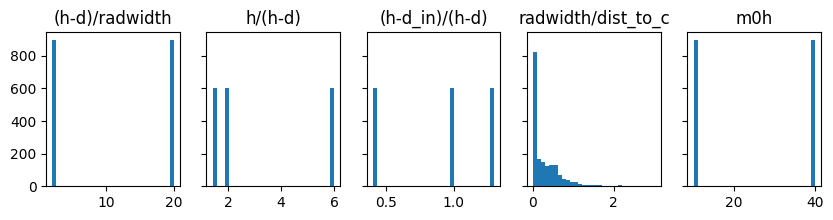

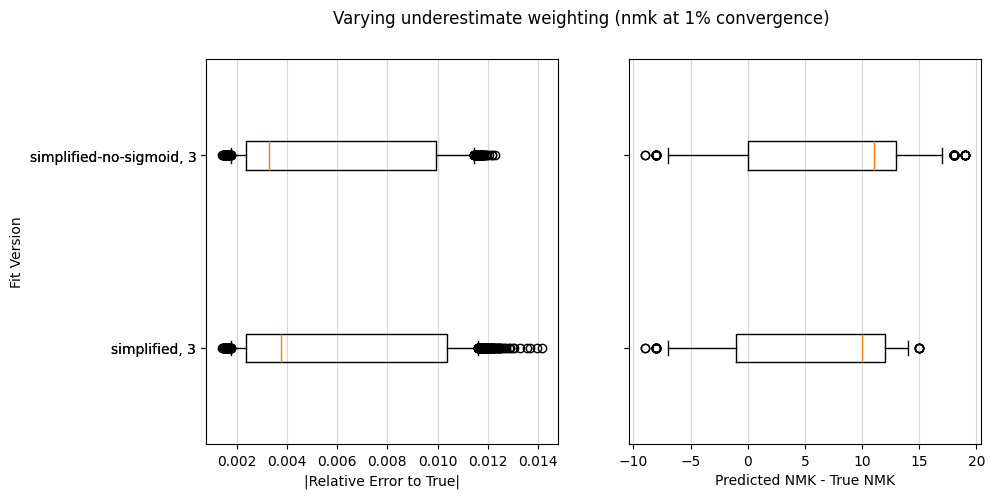

Sample size: 1800
Average Errors: 0.00592,0.00537
STDEV Errors: 0.00396,0.00375
Average NMK off: 6.21,7.32
STDEV NMK off: 7.27,7.65


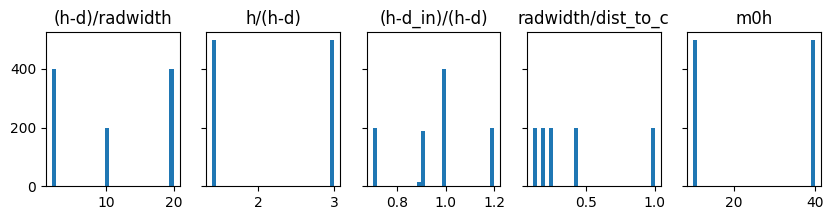

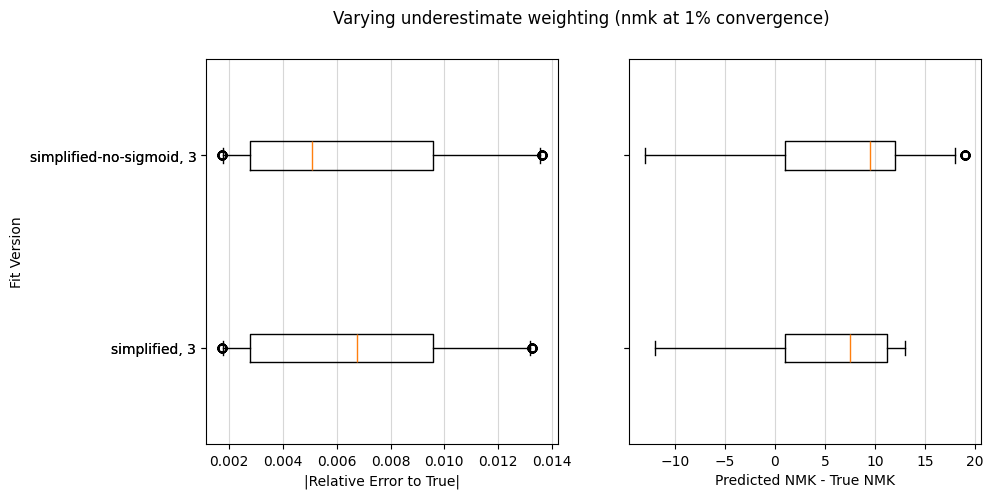

Sample size: 1000
Average Errors: 0.0065,0.00617
STDEV Errors: 0.00376,0.00383
Average NMK off: 5.15,6.55
STDEV NMK off: 7.47,8.53


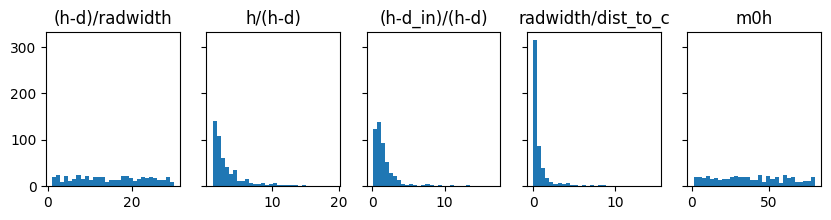

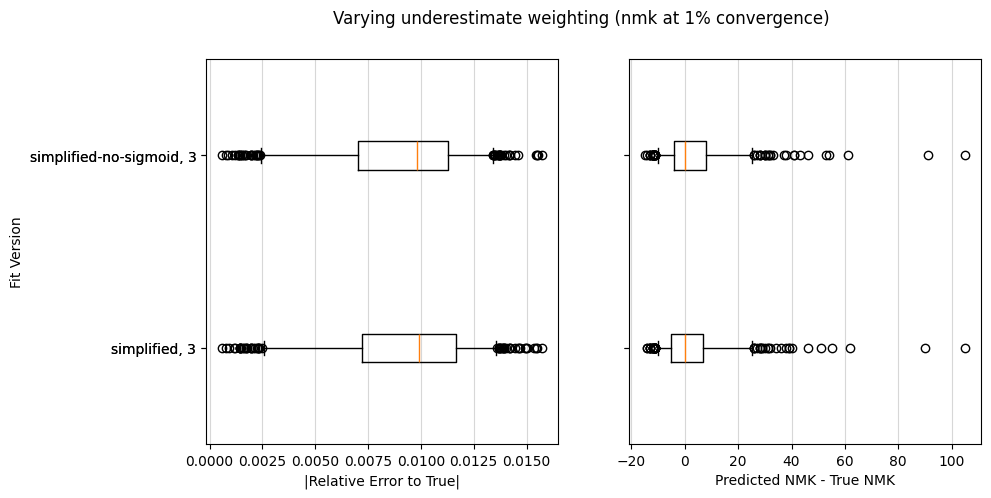

Sample size: 509
Average Errors: 0.00925,0.00903
STDEV Errors: 0.00337,0.00328
Average NMK off: 2.7,3.2
STDEV NMK off: 12.5,12.5


In [29]:
for dataset in [all_f3_data,all_f11_data,all_f12_data,all_f13_data, test_set_22]:
  ref = outermost_vars(1,[1,2,3],[1,2,3],1)
  outer_vars_collection = [outermost_vars_cf(cf, cf["m0s"][0]) for cf in dataset]
  outer_vars_dict = {key : [cf[key] for cf in outer_vars_collection] for key in ref.keys()}
  fig, axs = plt.subplots(1, 5, figsize = (10, 2), sharey=True)
  count = 0
  for key in ref.keys():
    axs[count].hist(outer_vars_dict[key], bins = 30)
    axs[count].set_title(key)
    count+=1
  plt.show()
  statpacks = compare_abs_nmk_rel_err(dataset, hydro, params_dict, 0.01, nmk_big = 200, title = "Varying underestimate weighting (nmk at 1% convergence)")
  print_err_nmk_abs_from_statpacks(statpacks)

In [30]:
# Outermost region, damping
def outer_model_dp_hmdr_hmd1():
  def model_vars(vars, a1, a2, b2):
    hmdr, left_ratio = vars
    alpha = a1
    beta = a2 * hmdr + b2
    return alpha, beta
  variables_used = ["(h-d)/radwidth", "(h-d_in)/(h-d)"]
  guess = [1.35, 0.02, 2.4]
  return model_vars, variables_used, guess

def outer_model_dp_m0h():
  def model_vars(vars, a1, b1, a2):
    hmdr, left_ratio, m0h = vars
    alpha = a1 * np.exp(-b1 * m0h) + 1
    beta = a2 * ((m0h ** 0.5) * (m0h > 5) + m0h/(5**0.5) * (m0h <=5))
    return alpha, beta
  variables_used = ["(h-d)/radwidth", "(h-d_in)/(h-d)", "m0h"]
  guess = [0.5, 0.016, 0.7]
  return model_vars, variables_used, guess

def outer_model_hhmd():
  def model_vars(vars, a1, b1, c1, a2, b2):
    hmdr, left_ratio, m0h, right_ratio = vars
    alpha = a1 * np.log(right_ratio + c1) + b1
    beta = a2 * np.exp(-b2 * right_ratio)
    return alpha, beta
  variables_used = ["(h-d)/radwidth", "(h-d_in)/(h-d)", "m0h", "h/(h-d)"]
  guess = [0.5, 0.016, 0, 4.5, 0.09]
  return model_vars, variables_used, guess

def outer_model_dp_hmdr_hmd1_m0h():
  def model_vars(vars, a1, b1, a2, b2):
    hmdr, left_ratio, m0h = vars
    alpha = a1 * np.exp(-b1 * m0h) + 1
    beta = (a2 * hmdr + b2) * ((m0h ** 0.5) * (m0h > 5) + m0h/(5**0.5) * (m0h <=5))
    return alpha, beta
  variables_used = ["(h-d)/radwidth", "(h-d_in)/(h-d)", "m0h"]
  guess = [0.5, 0.01, 2, 0.1]
  return model_vars, variables_used, guess

def outer_model_dp(): # independent of left ratio, m0h dependencies linked
  def model_vars(vars, a1, b1, c1, b2, a3, b3, b4):
    hmdr, m0h, right_ratio = vars
    alpha = (log_like(a1, b1, c1, right_ratio)) * np.exp(-b2 * m0h) + 1
    beta = (np.exp(-b4 * right_ratio)) * (a3 * hmdr + b3) * ((m0h ** 0.5) * (m0h > 5) + m0h/(5**0.5) * (m0h <=5))
    return alpha, beta
  variables_used = ["(h-d)/radwidth", "m0h", "h/(h-d)"]
  guess = [0.5, 0.016, 0, 0.01, 0.09, 2, 0.1]
  return model_vars, variables_used, guess

def outer_model_dp2(): # m0h dependencies separated
  def model_vars(vars, a1, b1, c1, b2,
                 a3, b3,
                 b4, a5, b5, a6):
    hmdr, m0h, right_ratio = vars
    alpha1 = (log_like(a1, b1, c1, right_ratio)) * np.exp(-b2 * m0h) + 1
    alpha2 = (log_like(a1, b1, c1, right_ratio)) * a3 * m0h + b3 
    beta1 = (np.exp(-b4 * right_ratio)) * (a5 * hmdr + b5) * ((m0h ** 0.5))
    beta2 = (np.exp(-b4 * right_ratio)) * (a5 * hmdr + b5) * a6 * m0h
    return alpha1 * (m0h > 5) + alpha2 * (m0h <= 5), beta1 * (m0h > 5) + beta2 * (m0h <= 5)
  variables_used = ["(h-d)/radwidth", "m0h", "h/(h-d)"]
  guess = [0.5, 0.016, 0, 0.01, 1, 1, 0.1, 0.09, 2, 0.5]
  return model_vars, variables_used, guess

Finished a model.
Finished a model.
Finished a model.
Finished a model.
Finished a model.
Finished a model.


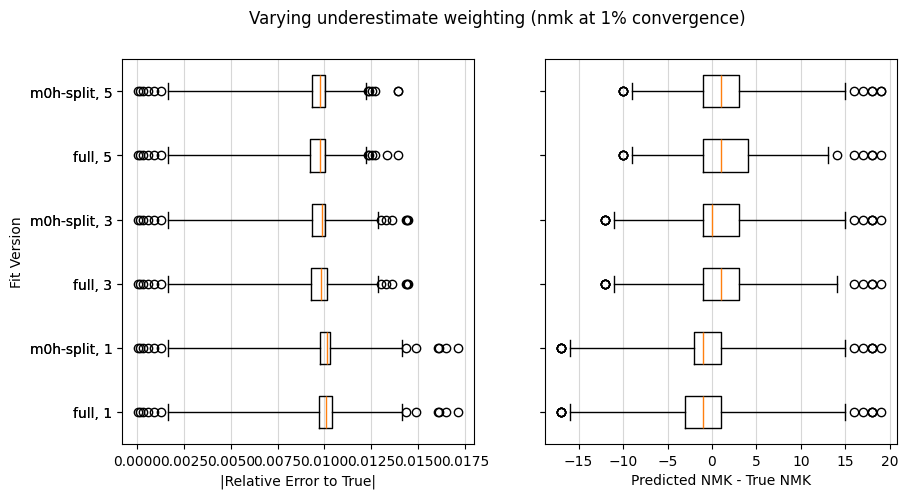

Sample size: 105
Average Errors: 0.00974,0.00969,0.00928,0.00924,0.00911,0.0091
STDEV Errors: 0.00325,0.00326,0.00291,0.00292,0.00277,0.0028
Average NMK off: -0.581,-0.381,1.36,1.57,2.01,2.1
STDEV NMK off: 7.9,8.05,6.6,6.92,6.11,6.49


In [31]:
cfs, hydro = f3_data[1] + f3_data[2] + f3_data[4] + f3_data[6], "dp"
params_dict= {}
underweight_lst = [1, 3, 5]
curve_names = ["full", "m0h-split"]
model_packs = [variables_guess_variants(outer_model_dp, "outermost"), variables_guess_variants(outer_model_dp2, "outermost")]
for underweight in underweight_lst:
  for i in range(2):
    variables_used, guess, fit_model, cf_params_to_alpha_beta, err_from_nmk_model, nmk_from_err_model = model_packs[i]
    params, res = fit_outer_model_weighted(cfs, hydro, fit_model, guess, variables_used,  underweight = underweight)
    key = curve_names[i] + ", " + str(underweight)
    params_dict[key] = (twenty_minimum(nmk_from_err_model), params)
    print("Finished a model.")
statpacks = compare_abs_nmk_rel_err(cfs, hydro, params_dict, 0.01, nmk_big = 200, title = "Varying underestimate weighting (nmk at 1% convergence)")
print_err_nmk_abs_from_statpacks(statpacks)

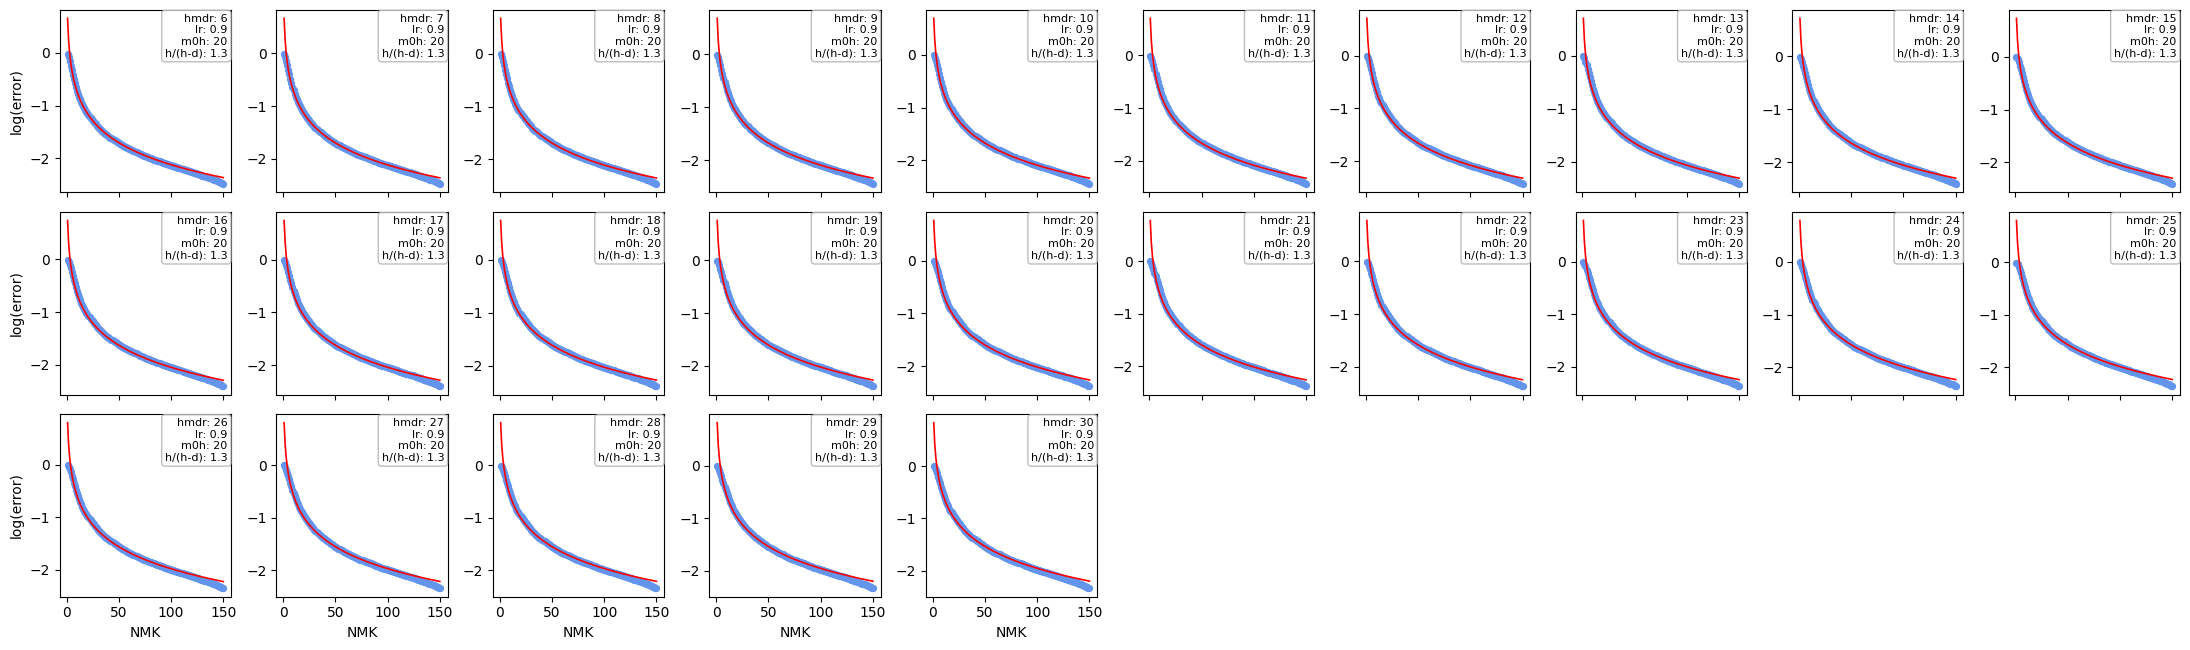

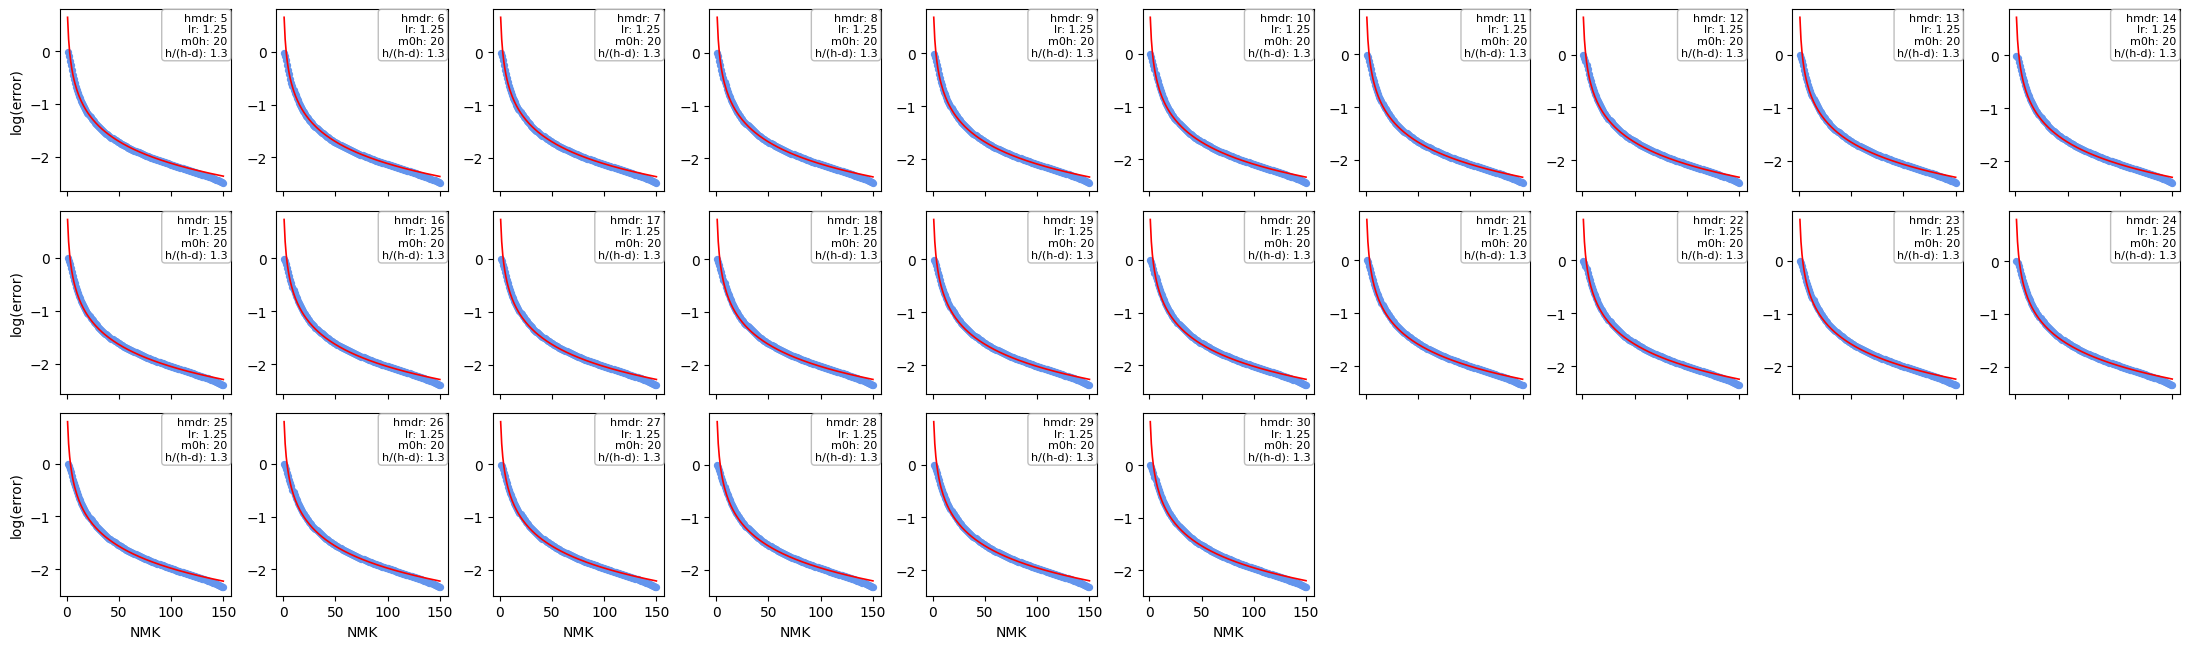

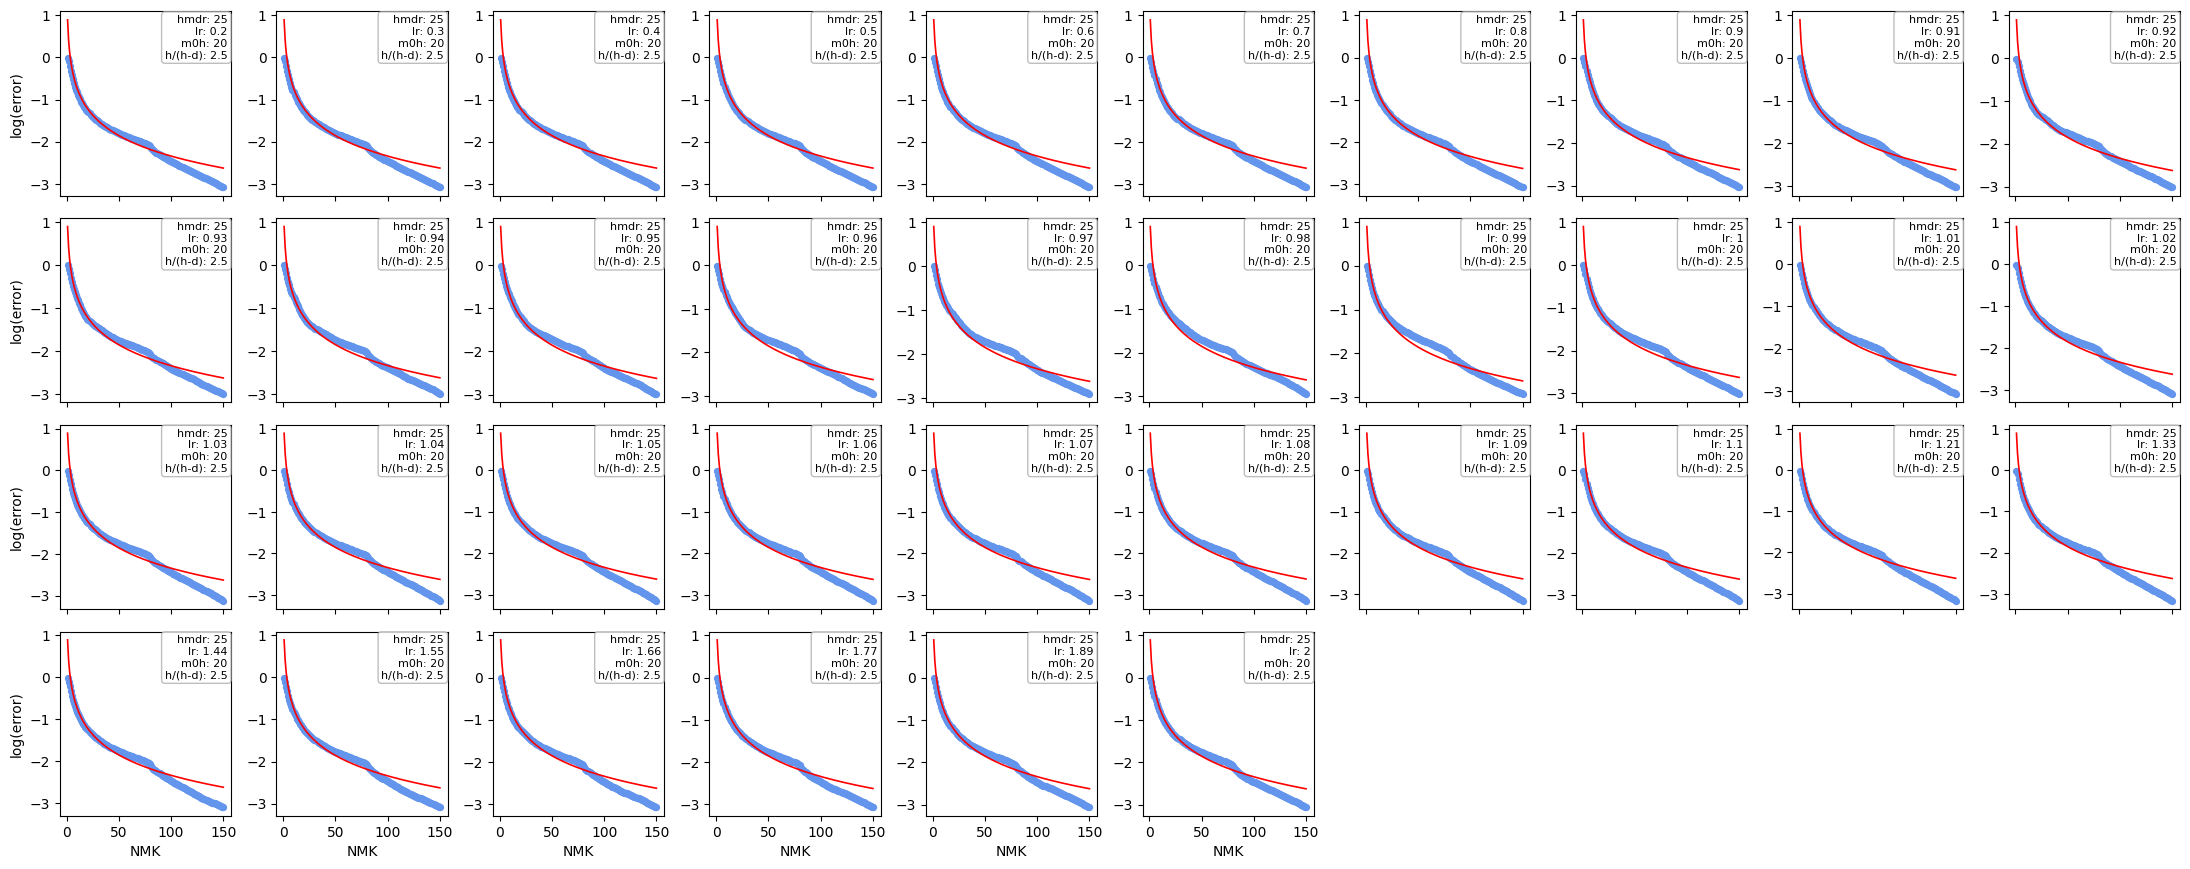

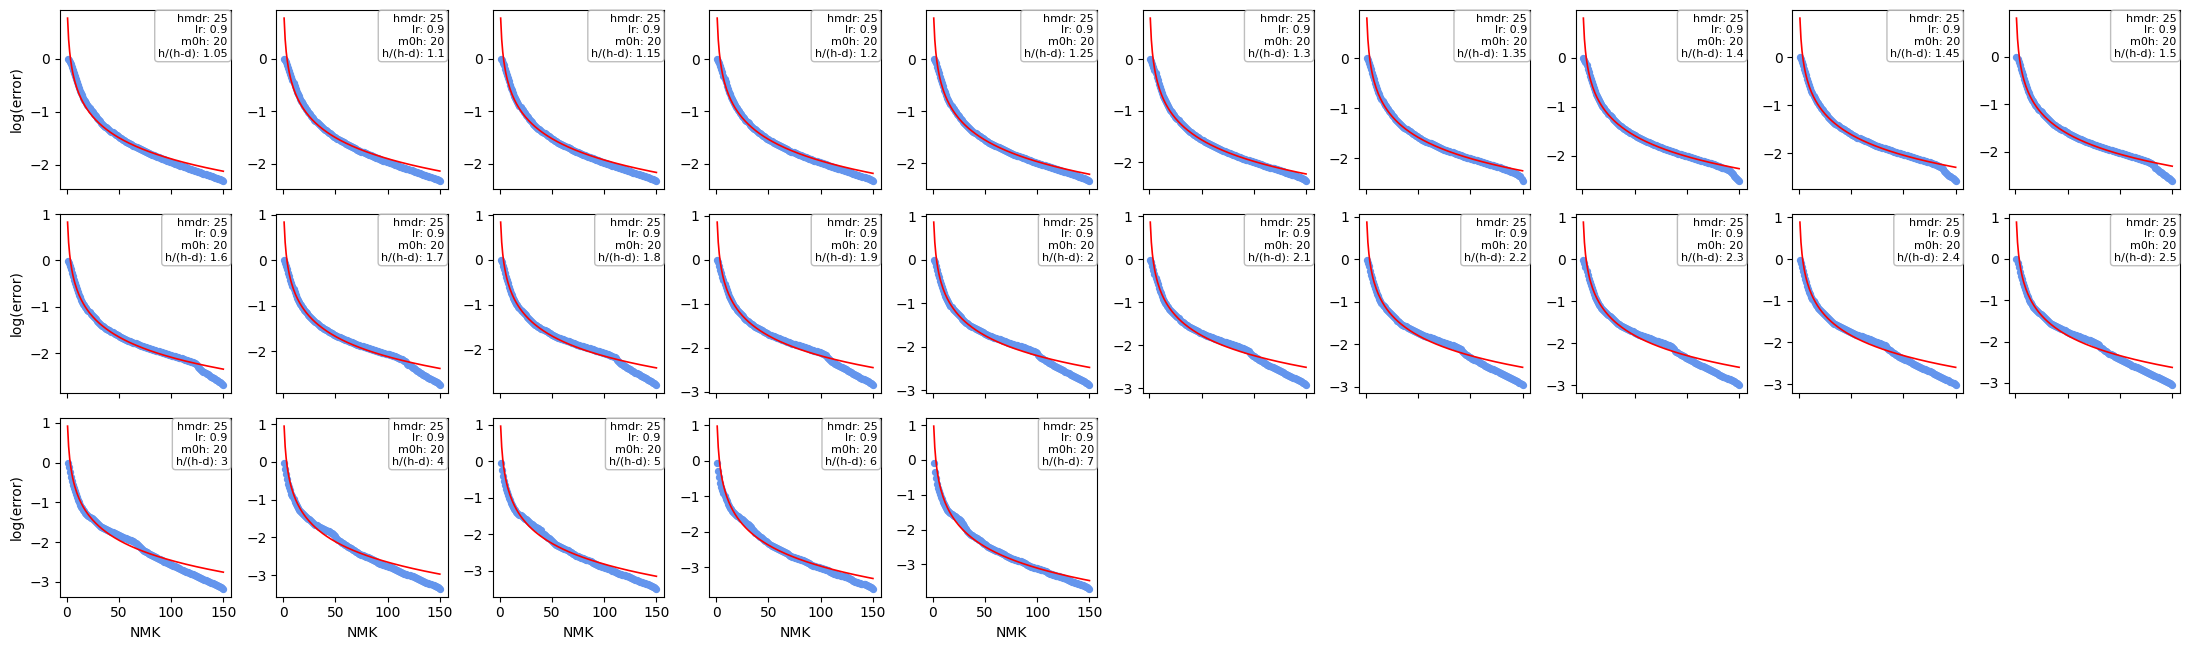

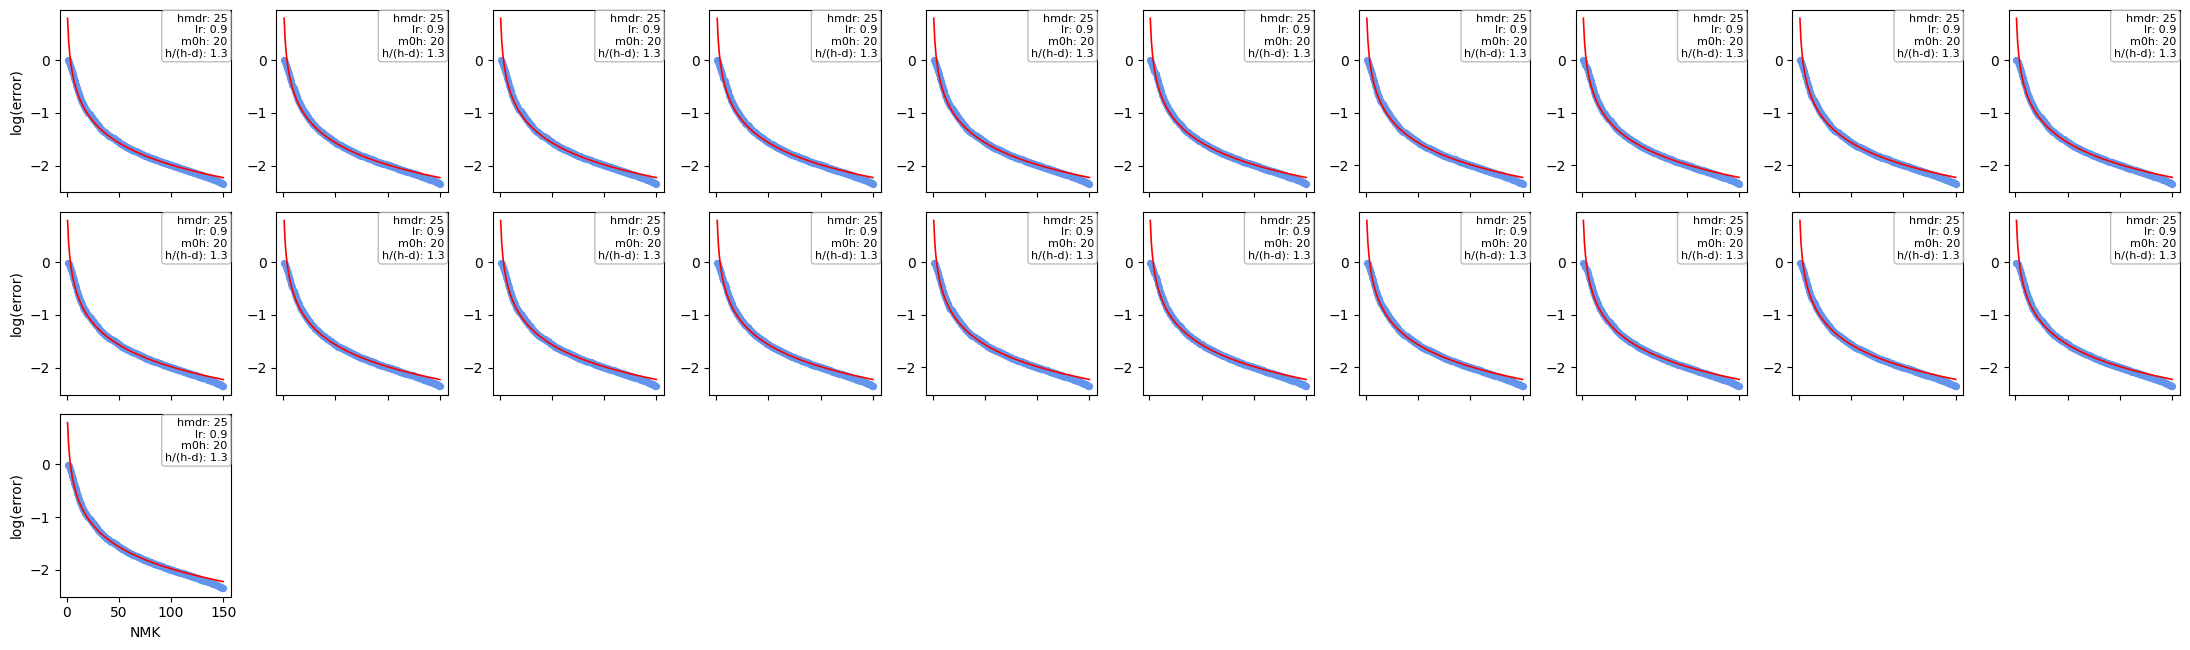

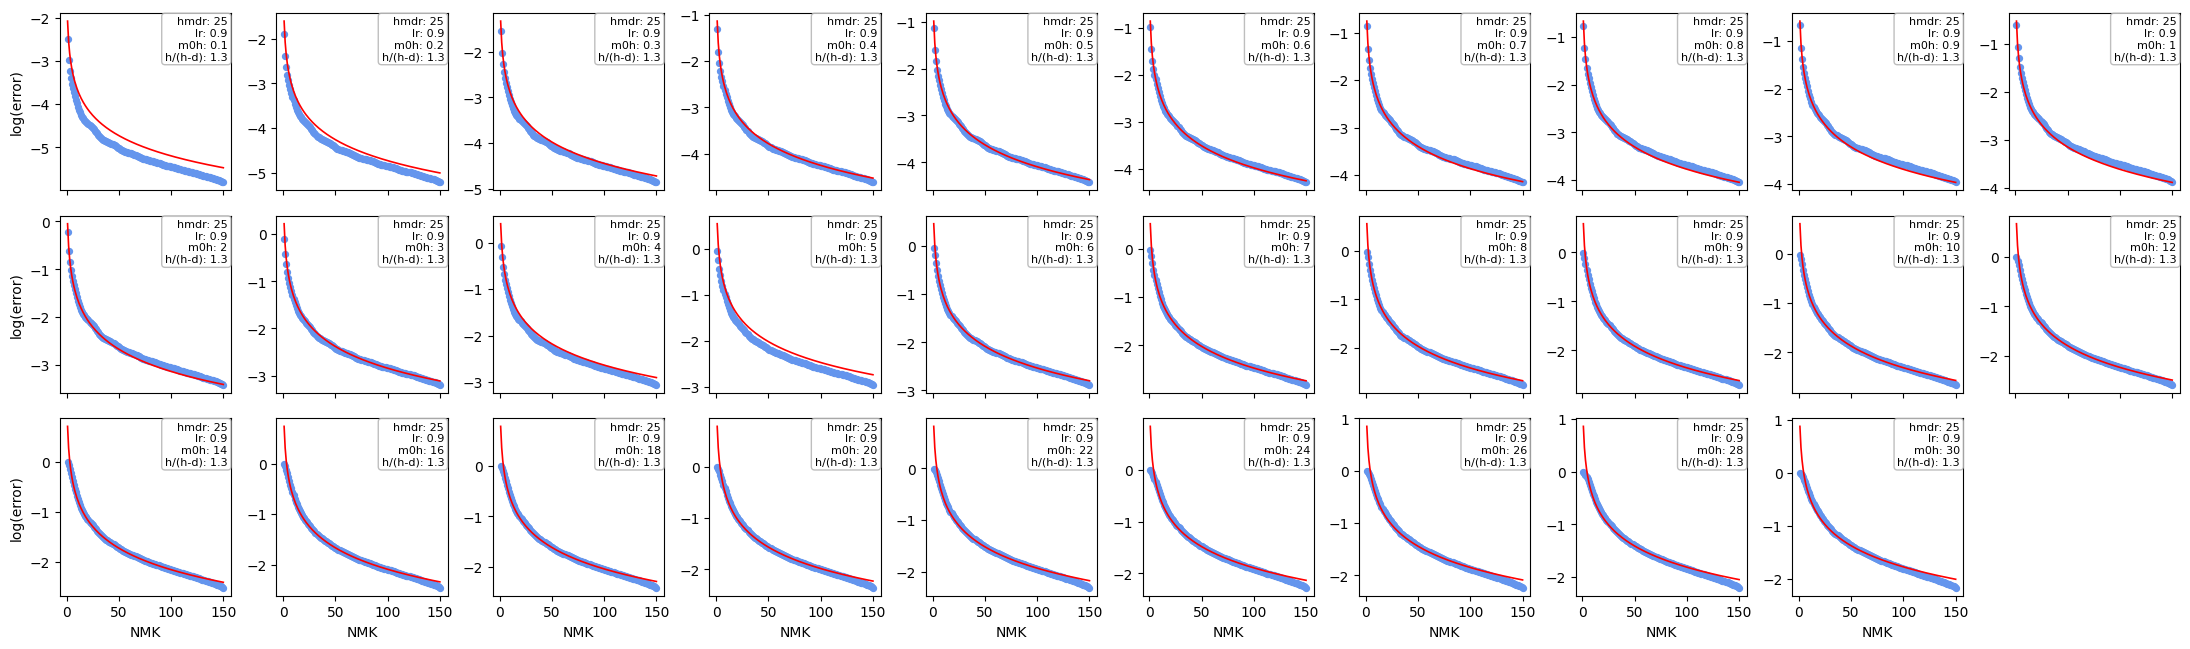

In [32]:
summary_fs = {"hmdr" : lambda cf : (cf["h"]-cf["d"][2])/(cf["a"][2]-cf["a"][1]),
              "lr" : lambda cf : (cf["h"]-cf["d"][1])/(cf["h"]-cf["d"][2]),
              "m0h" : lambda cf : cf["h"] * cf["m0s"][0],
              "h/(h-d)" : lambda cf : cf["h"] / (cf["h"]-cf["d"][2])}
for i in range(1, 7):
  compare_model_curves(f3_data[i], extractf_dp, model_wrapper(lambda cf, m0 : cf_params_to_alpha_beta(cf, m0, *params_dict["m0h-split, 3"][1])), summary_fs)

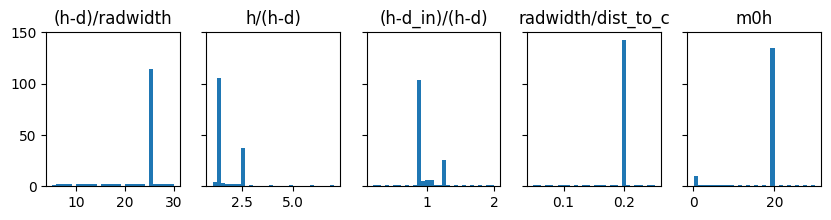

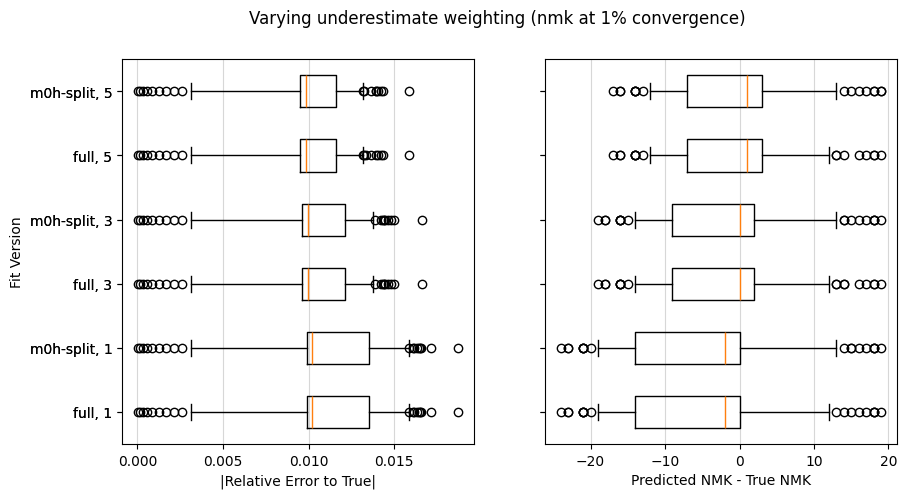

Sample size: 163
Average Errors: 0.0109,0.0109,0.0102,0.0102,0.00997,0.00997
STDEV Errors: 0.00339,0.00341,0.00289,0.00291,0.00271,0.00273
Average NMK off: -4.44,-4.31,-1.81,-1.67,-0.816,-0.761
STDEV NMK off: 9.76,9.89,8.14,8.36,7.49,7.71


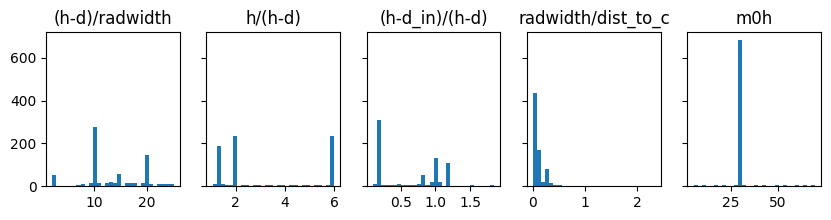

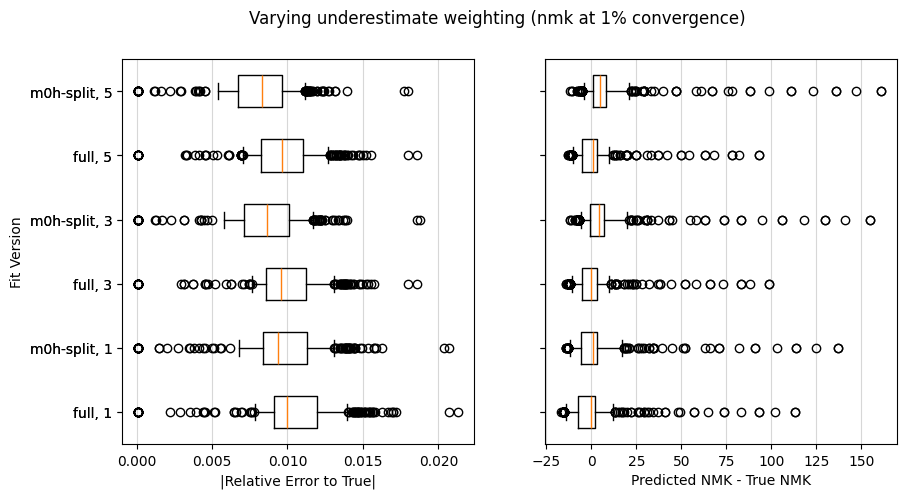

Sample size: 751
Average Errors: 0.0103,0.00962,0.0098,0.00845,0.00962,0.00807
STDEV Errors: 0.00265,0.00266,0.00239,0.00242,0.00227,0.00235
Average NMK off: -0.595,2.15,0.322,6.15,0.63,7.55
STDEV NMK off: 13.6,15.8,11.6,16.7,10.9,17


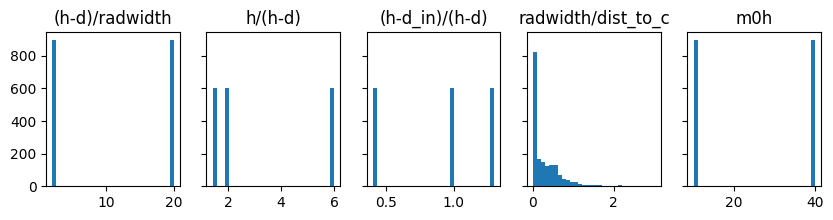

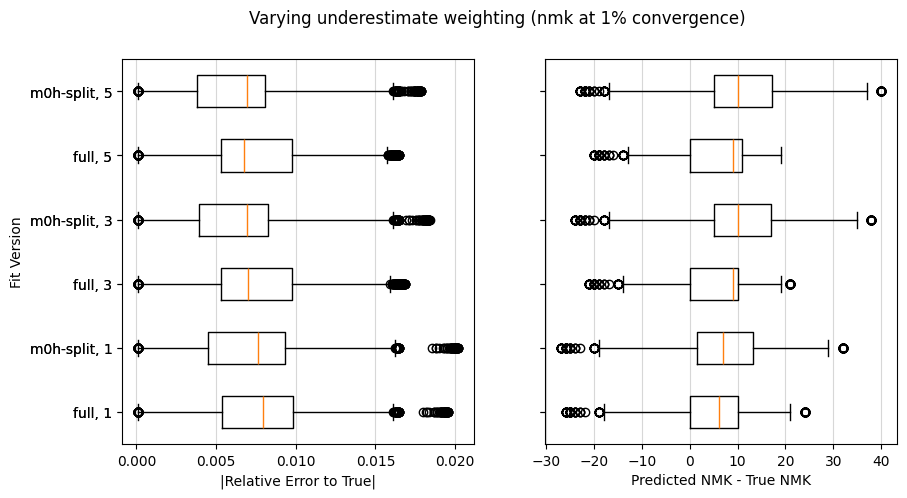

Sample size: 1800
Average Errors: 0.00795,0.00748,0.0076,0.00684,0.00754,0.0067
STDEV Errors: 0.00414,0.00429,0.00379,0.00414,0.00375,0.00414
Average NMK off: 4.87,7.45,5.62,10.8,5.62,11.8
STDEV NMK off: 10.2,12.4,8.95,13.9,8.67,14.7


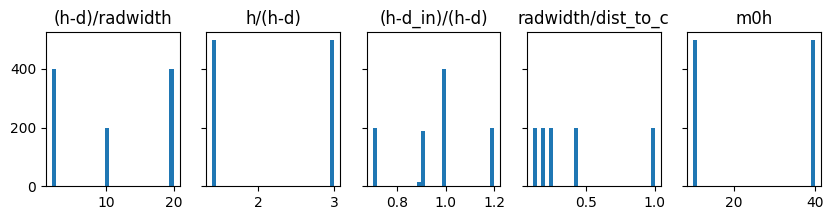

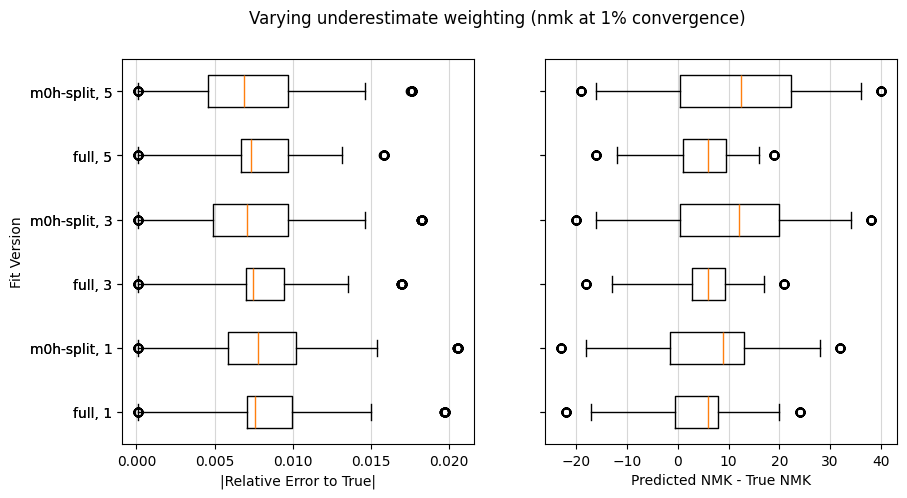

Sample size: 1000
Average Errors: 0.00861,0.00808,0.00804,0.00722,0.00782,0.00704
STDEV Errors: 0.00436,0.00502,0.0037,0.00457,0.00352,0.00451
Average NMK off: 3.85,6.55,4.8,10.5,5.15,11.6
STDEV NMK off: 10.6,13.5,8.89,15,8.28,15.6


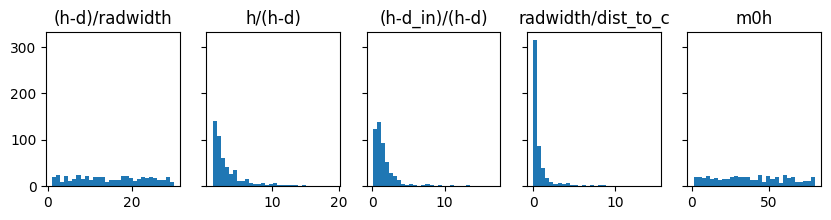

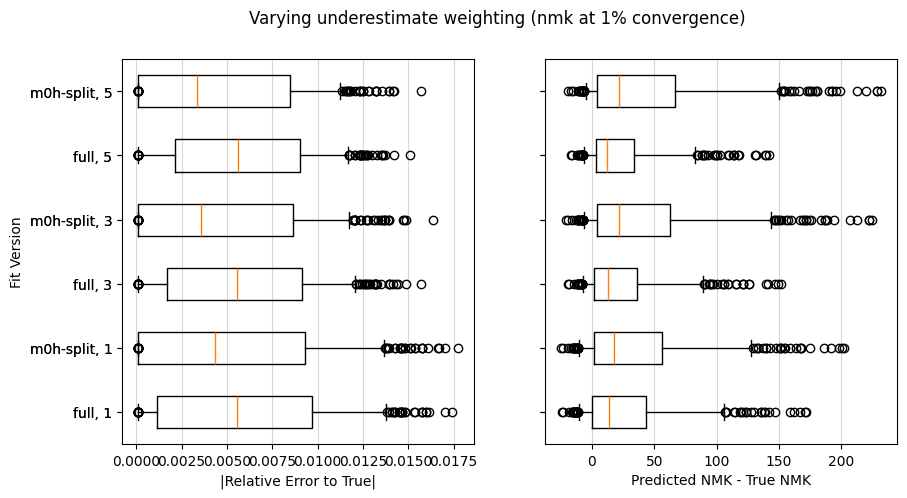

Sample size: 509
Average Errors: 0.00579,0.00525,0.00558,0.00466,0.00556,0.00446
STDEV Errors: 0.00466,0.00477,0.00415,0.00435,0.00396,0.00422
Average NMK off: 27.2,35,24.2,41.1,23,43.2
STDEV NMK off: 37.6,45.6,31.7,50.1,29.3,51.6


In [33]:
for dataset in [all_f3_data,all_f11_data,all_f12_data,all_f13_data,test_set_22]:
  ref = outermost_vars(1,[1,2,3],[1,2,3],1)
  outer_vars_collection = [outermost_vars_cf(cf, cf["m0s"][0]) for cf in dataset]
  outer_vars_dict = {key : [cf[key] for cf in outer_vars_collection] for key in ref.keys()}
  fig, axs = plt.subplots(1, 5, figsize = (10, 2), sharey=True)
  count = 0
  for key in ref.keys():
    axs[count].hist(outer_vars_dict[key], bins = 30)
    axs[count].set_title(key)
    count+=1
  plt.show()
  statpacks = compare_abs_nmk_rel_err(dataset, "dp", params_dict, 0.01, nmk_big = 200, title = "Varying underestimate weighting (nmk at 1% convergence)")
  print_err_nmk_abs_from_statpacks(statpacks)

269.0 141


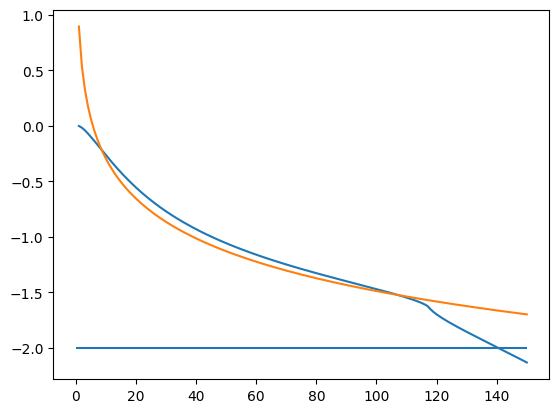

In [34]:
variables_used, guess, fit_model, cf_params_to_alpha_beta, err_from_nmk_model, nmk_from_err_model = variables_guess_variants(outer_model_dp, "outermost")
params, res = fit_outer_model_weighted(cfs, hydro, fit_model, guess, variables_used,  underweight = 1)
test_restrict_1 = [cf for cf in test_set_22 if (cf["m0s"][0] * cf["h"]) > 70]
for cf in test_restrict_1[:1]:
  a1, b1 = cf_params_to_alpha_beta(cf, cf["m0s"][0], *params)
  # pack = fit_parameters(cf, cf["m0s"][0], "dp", nmk_max = 120, print_params = True, underweight = 1)
  # a2, b2 = pack[0]
  xs = range(1, 151)
  ys1 = [entry / np.log(10) for entry in cf[cf["m0s"][0]]["log errors dp"]]
  ys2 = [-a1 * np.log(x / b1) / np.log(10) for x in xs]
  # ys3 = [-a2 * np.log(x / b2) for x in xs]
  # ys4 = cf[cf["m0s"][0]]["log errors am"]
  print(np.ceil(nmk_from_err_model(0.01, cf, cf["m0s"][0], *params)), cf[cf["m0s"][0]]["convergence point 0.01 dp"])
  plt.plot(xs, ys1)
  plt.plot(xs, ys2)
  # plt.plot(xs, ys3)
  # plt.plot(xs, ys4)
  plt.hlines(np.log10(0.01), 0, 150)
  plt.show()

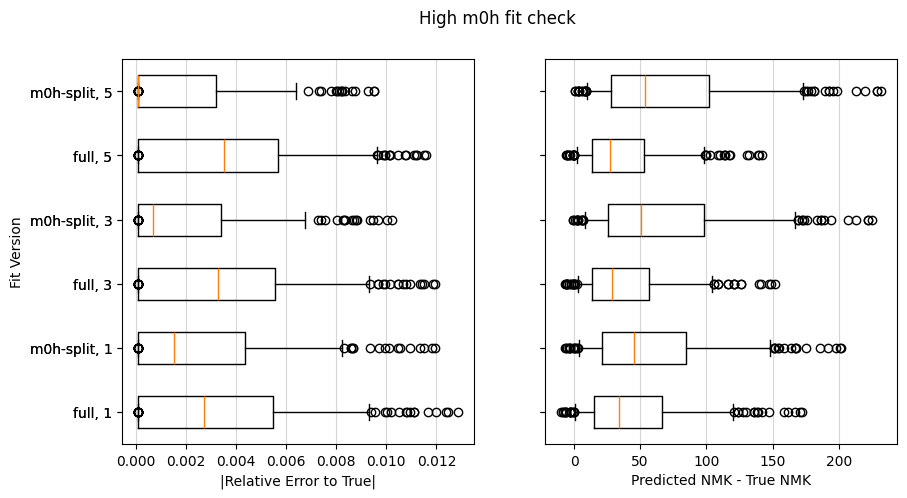

Sample size: 310


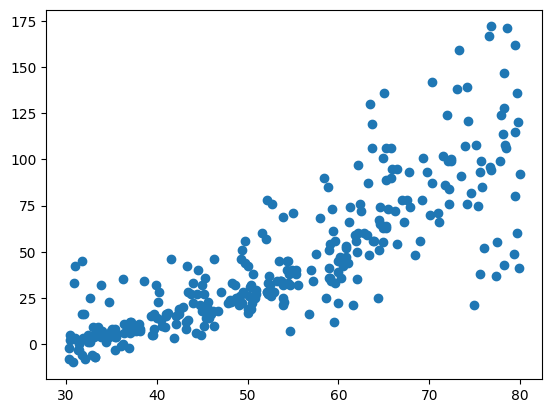

In [35]:
test_restrict_2 = [cf for cf in test_set_22 if (cf["m0s"][0] * cf["h"]) > 30]
xs = [cf["m0s"][0] * cf["h"] for cf in test_restrict_2]
statpacks = compare_abs_nmk_rel_err(test_restrict_2, "dp", params_dict, 0.01, nmk_big = 200, title = "High m0h fit check")
ys = statpacks[1][0][0]
plt.scatter(xs, ys)